# Test Práctico - Científico de Datos SICEX
## Desafío: Unificación y Normalización de Entidades

## Introducción

Este notebook está estructurado para evaluar tus habilidades en el análisis y procesamiento de datos de comercio exterior. Contiene cuatro bloques principales con objetivos claros. Completa cada bloque según las instrucciones. Las tareas avanzadas son opcionales y te permitirán ganar puntos extra.

### CONTEXTO:
SICEX maneja grandes volúmenes de datos de comercio exterior donde uno de los principales 
desafíos es la consistencia y normalización de entidades como nombres de empresas,
ciudades y productos. Este test evaluará tu capacidad para proponer e implementar
soluciones a este problema real.

### OBJETIVOS DE EVALUACIÓN:
- Capacidad de análisis y limpieza de datos
- Habilidad para desarrollar algoritmos de matching y normalización
- Pensamiento creativo en la resolución de problemas
- Capacidad de escalar soluciones
- Documentación y comunicación técnica


In [ ]:
# Configuración inicial
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
nltk.download('stopwords')
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from difflib import SequenceMatcher
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from unidecode import unidecode
from fuzzywuzzy import fuzz
from rapidfuzz import fuzz as rfuzz
from sentence_transformers import SentenceTransformer, util
from transformers import BertTokenizer, BertModel
import torch
!pip install groq python-dotenv
!pip install sentence-transformers transformers torch
!pip install fuzzywuzzy
!pip install rapidfuzz
!pip install spacy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
import spacy
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
import warnings
warnings.filterwarnings('ignore')
from etl_data_science_test import config

### **Bloque 1: Análisis Exploratorio (EDA)**

#### Objetivo
Familiarízate con el dataset proporcionado y realiza un análisis básico para identificar patrones, inconsistencias y oportunidades de limpieza.


In [149]:
# 1. Cargar datos
file_path = os.path.join(config.RAW_DATA_DIR, "10_Importaciones_2024_Octubre.xlsb")

def load_and_examine_data(file_path):
    """
    Función para cargar y examinar un archivo .xlsb.
    Muestra información básica del dataset.
    """
    try:
        df = pd.read_excel(file_path, engine='pyxlsb')
        
        # Información básica del dataset
        print("=== INFORMACIÓN BÁSICA DEL DATASET ===")
        print(f"Número de registros: {len(df)}")
        print(f"Número de columnas: {len(df.columns)}")
        print("Nombres de las columnas:", df.columns.tolist())
        print("\nTipos de datos:")
        print(df.dtypes)
        print("\nValores nulos por columna:")
        print(df.isnull().sum())
        print("\nValores únicos por columna:")
        print(df.nunique())
        return df
    except Exception as e:
        print(f"Error al cargar el archivo: {e}")
        return None

##  EJERCICIO 1: ANÁLISIS EXPLORATORIO Y DIAGNÓSTICO 

Trabajaremos con un dataset real de importaciones que contiene información sobre empresas
y ubicaciones. Tu primera tarea es realizar un análisis exploratorio enfocado en 
la calidad de los datos de las entidades.

### Analiza específicamente:
1. Nombres de empresas (NOMBRE_IMPORTADOR, NOMBRE_EXPORTADOR)
2. Ubicaciones (CIUDAD_PAIS_EXPORTADOR, DEPARTAMENTO_IMPORTADOR)
3. Direcciones (DIRECCION_IMPORTADOR, DIRECCION_EXPORTADOR)

### Para cada campo:
- Identifica patrones en las inconsistencias
- Cuantifica el impacto de estas inconsistencias
- Propón una estrategia de limpieza y normalización


In [151]:
def analyze_entity_fields(df):
    """
    Análisis de campos clave: nombres, ubicaciones y direcciones, con visualizaciones estrategicas.
    """
    entity_fields = [
        "NOMBRE_IMPORTADOR", "NOMBRE_EXPORTADOR",
        "CIUDAD_PAIS_EXPORTADOR", "DEPARTAMENTO_IMPORTADOR",
        "DIRECCION_IMPORTADOR", "DIRECCION_EXPORTADOR"
    ]

    print("\n=== ANÁLISIS DE ENTIDADES ===")
    for field in entity_fields:
        print(f"\n--- Análisis para: {field} ---")
        print(f"Valores únicos: {df[field].nunique()}")
        print(f"Valores nulos: {df[field].isnull().sum()} ({(df[field].isnull().mean() * 100):.2f}%)")
        print(f"Duplicados: {df[field].duplicated().sum()}")

        if df[field].dtype == 'object':
            print(f"Frecuencia de valores más comunes:\n{df[field].value_counts().head(5)}")

            # Gráfico de barras para valores más comunes
            plt.figure(figsize=(10, 5))
            df[field].value_counts().head(5).plot(kind='bar', color='skyblue')
            plt.title(f"Frecuencia de Valores Más Comunes en {field}")
            plt.ylabel("Frecuencia")
            plt.xlabel("Valores")
            plt.xticks(rotation=45)
            plt.show()

        # Análisis de patrones en longitud de cadenas
        if df[field].dtype == 'object':
            plt.figure(figsize=(10, 5))
            sns.histplot(df[field].str.len().dropna(), bins=20, kde=True, color='coral', alpha=0.7)
            plt.title(f"Distribución de Longitudes en {field}")
            plt.xlabel("Longitud de Cadena")
            plt.ylabel("Frecuencia")
            plt.show()

        # Grafico para patrones de datos nulos
        if df[field].isnull().any():
            null_counts = df[field].isnull().astype(int).value_counts()
            plt.figure(figsize=(6, 4))
            null_counts.plot(kind='bar', color=['orange', 'blue'])
            plt.title(f"Distribución de Nulos en {field}")
            plt.ylabel("Frecuencia")
            plt.xlabel("Estado (0=No Nulo, 1=Nulo)")
            plt.xticks(rotation=0)
            plt.show()

In [153]:
def analyze_patterns(df):
    """
    Identificación de patrones y anomalías en los campos clave estudiados.
    """
    print("\n=== ANÁLISIS DE PATRONES Y ANOMALÍAS ===")

   # Se busca correlación entre valores nulos, para establecer hipótesis de nulidad
    null_corr = df.isnull().corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(null_corr, cmap="coolwarm", cbar=True)
    plt.title("Correlación entre Valores Nulos")
    plt.show()

    # Se analizan las longitudes de cadenas en múltiples columnas
    text_fields = [
        "NOMBRE_IMPORTADOR", "NOMBRE_EXPORTADOR",
        "DIRECCION_IMPORTADOR", "DIRECCION_EXPORTADOR"
    ]

    for field in text_fields:
        lengths = df[field].str.len().dropna()
        if not lengths.empty:
            plt.figure(figsize=(10, 5))
            sns.boxplot(x=lengths, color='teal')
            plt.title(f"Distribución de Longitudes para {field}")
            plt.xlabel("Longitud de Cadena")
            plt.show()

    # Se analizan las cadenas de texto en busqueda de datos atípicos
    print("\n=== Análisis de Valores Atípicos ===")
    for field in text_fields:
        lengths = df[field].str.len().dropna()
        if not lengths.empty:
            q1 = lengths.quantile(0.25)
            q3 = lengths.quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers = lengths[(lengths < lower_bound) | (lengths > upper_bound)]
            print(f"Valores atípicos en {field}: {len(outliers)} encontrados")


=== INFORMACIÓN BÁSICA DEL DATASET ===
Número de registros: 201855
Número de columnas: 125
Nombres de las columnas: ['BANC_CODIGO_BANCO', 'COD_ADUANA_PRESENTADA', 'ADUANA_PRESENTADA', 'CODIGO_SUCURSAL', 'CODIGO_CAJERO', 'CONSECUTIVO_CAJERO', 'DIGITO_VERIFICACION_DOC', 'NUM_DECLARACION_ANT', 'FECHA_DECLARACION_ANT', 'MANIFIESTO_DE_CARGA', 'FECHA_MANIFIESTO', 'DOCUMENTO_TRANSPORTE', 'MODA_CODIGO_MODALIDAD', 'CODIGO_DEPOSITO', 'RAZON_SOCIAL_DECLARANTE', 'TIPO_IDENTIFICAC_DECLARAN', 'NIT_DECLARANTE', 'DIGITO_VERIFI_NIT_DECLARA', 'NOMBRE_IMPORTADOR', 'NIT_IMPORTADOR', 'DIGITO_VERIFI_NIT_IMPORTA', 'DIRECCION_IMPORTADOR', 'NOMBRE_EXPORTADOR', 'DIRECCION_EXPORTADOR', 'CIUDAD_PAIS_EXPORTADOR', 'ACTIVIDAD_ECONOMICA_SEC', 'CODIGO_PAIS_PROCEDENCIA', 'PAIS_PROCEDENCIA', 'COD_MODO_TRANSPORTE', 'MODO_TRANSPORTE', 'EMPRESA_TRANSPORTADORA', 'CODIGO_ENTIDAD_INTERMEDIA', 'TASA_CAMBIO', 'COD_DEPARTAMENTO_DESTINO', 'DEPARTAMENTO_DESTINO', 'COD_MODALIDAD_IMPORTACION', 'NUM_CUOTAS_O_MESES', 'SUBPARTIDA_ARANC

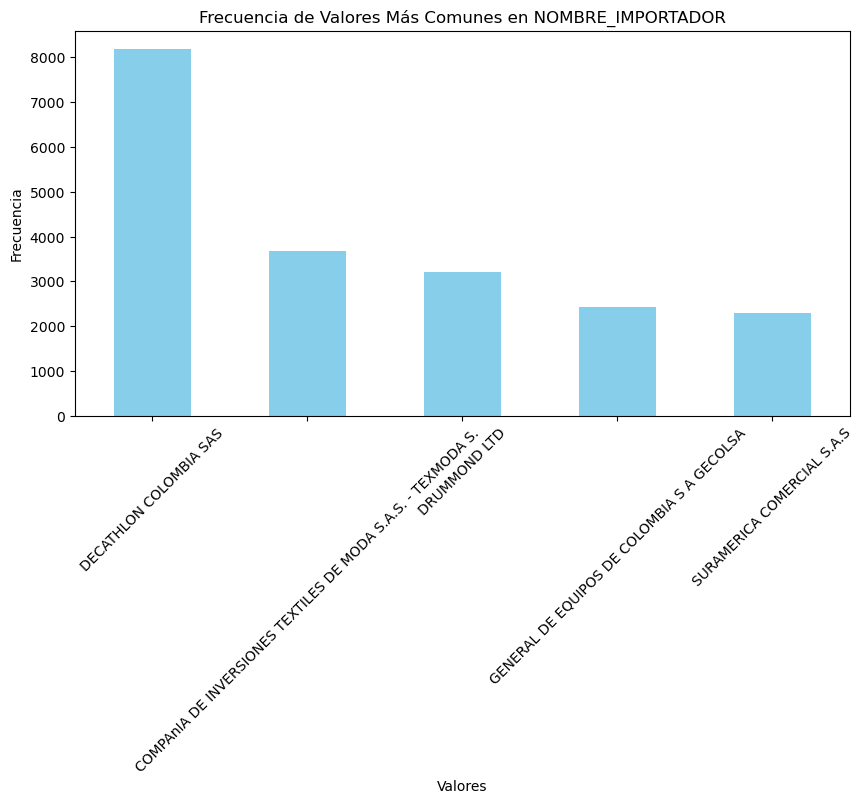

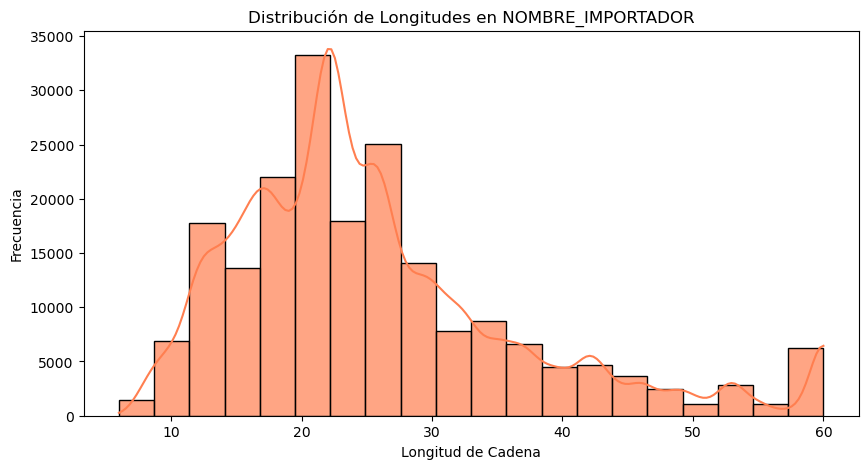


--- Análisis para: NOMBRE_EXPORTADOR ---
Valores únicos: 25455
Valores nulos: 0 (0.00%)
Duplicados: 176400
Frecuencia de valores más comunes:
NOMBRE_EXPORTADOR
DESIPRO PTE. LTD.                          8181
PANAMERICAN SERVICE CORPORATION            5703
INDITEX INDUSTRIA DE DISEnO TEXTIL S.A.    3056
GENERAL DOLLAR SOURCING INC.               2296
PRICESMART, INC.                           2125
Name: count, dtype: int64


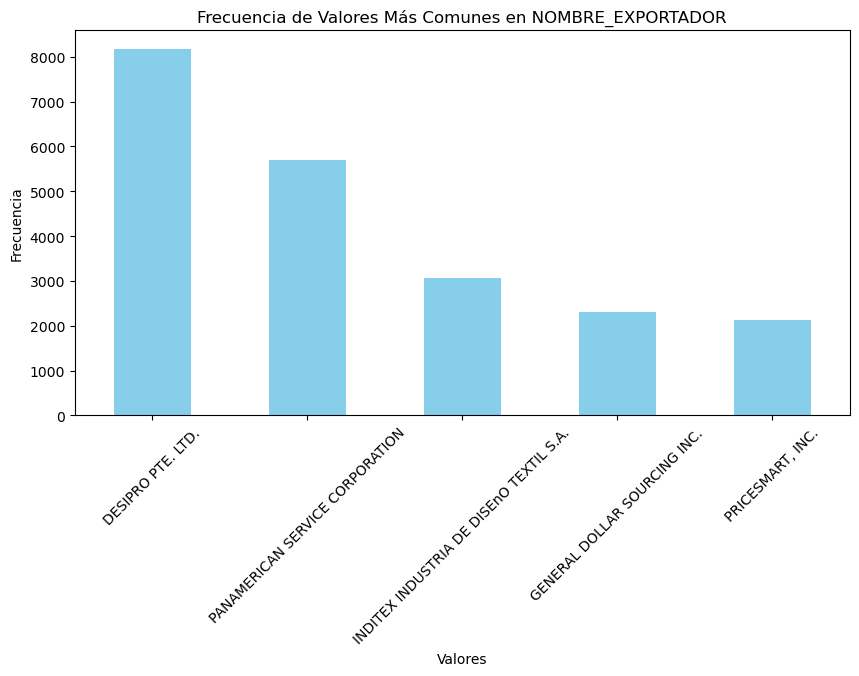

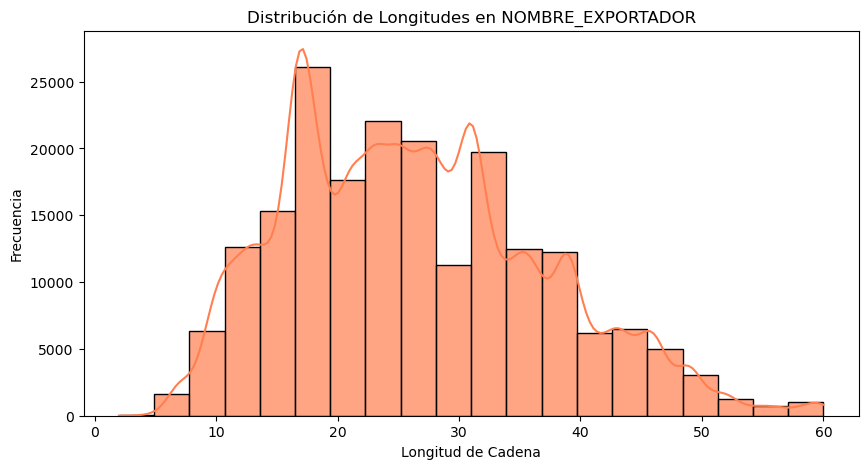


--- Análisis para: CIUDAD_PAIS_EXPORTADOR ---
Valores únicos: 8531
Valores nulos: 202 (0.10%)
Duplicados: 193323
Frecuencia de valores más comunes:
CIUDAD_PAIS_EXPORTADOR
SINGAPORE           8918
YIWU                7395
MIAMI               6535
LA CORUNA           6190
CIUDAD DE PANAMA    4807
Name: count, dtype: int64


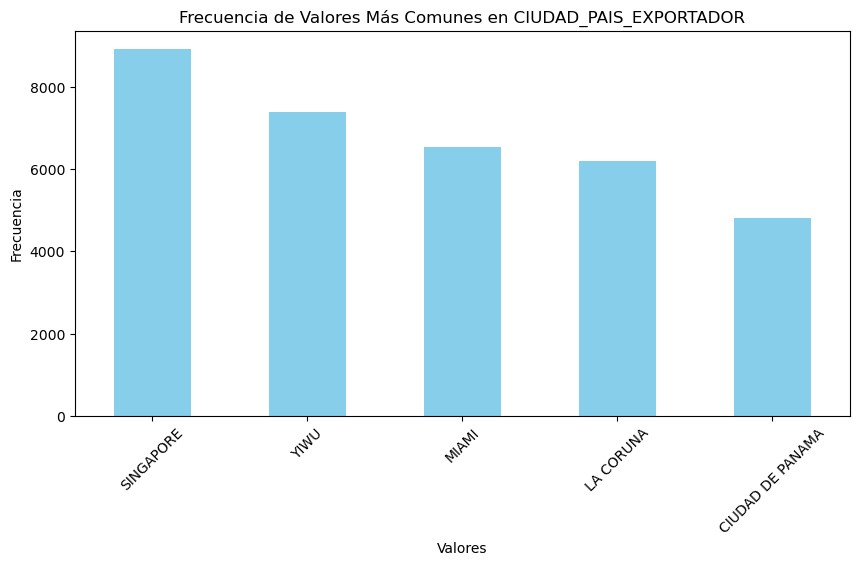

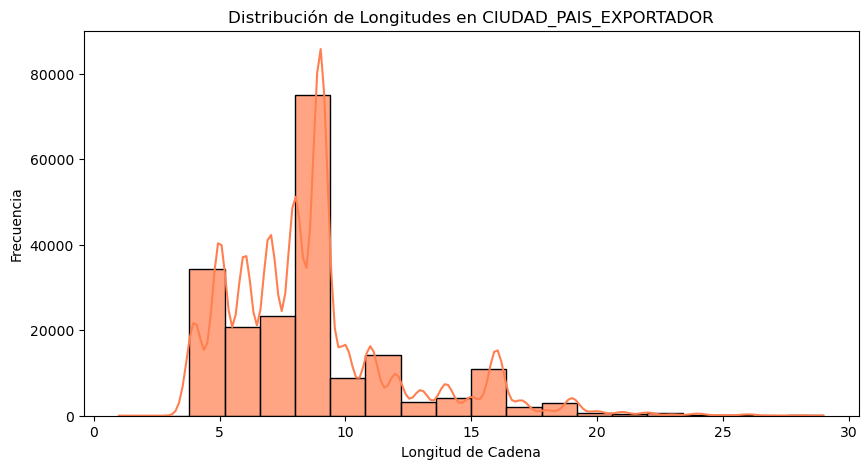

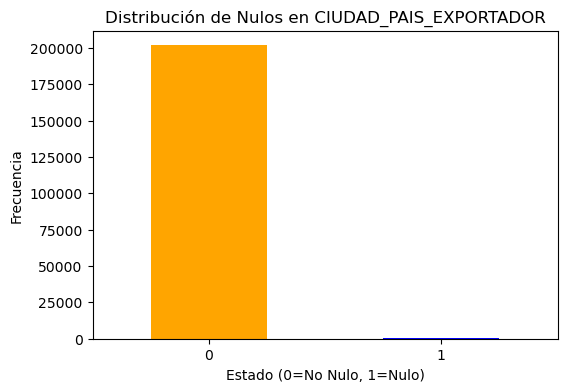


--- Análisis para: DEPARTAMENTO_IMPORTADOR ---
Valores únicos: 31
Valores nulos: 0 (0.00%)
Duplicados: 201824
Frecuencia de valores más comunes:
DEPARTAMENTO_IMPORTADOR
BOGOTA DC          111675
ANTIOQUIA           25446
CUNDINAMARCA        23767
VALLE DEL CAUCA     16689
ATLANTICO           10428
Name: count, dtype: int64


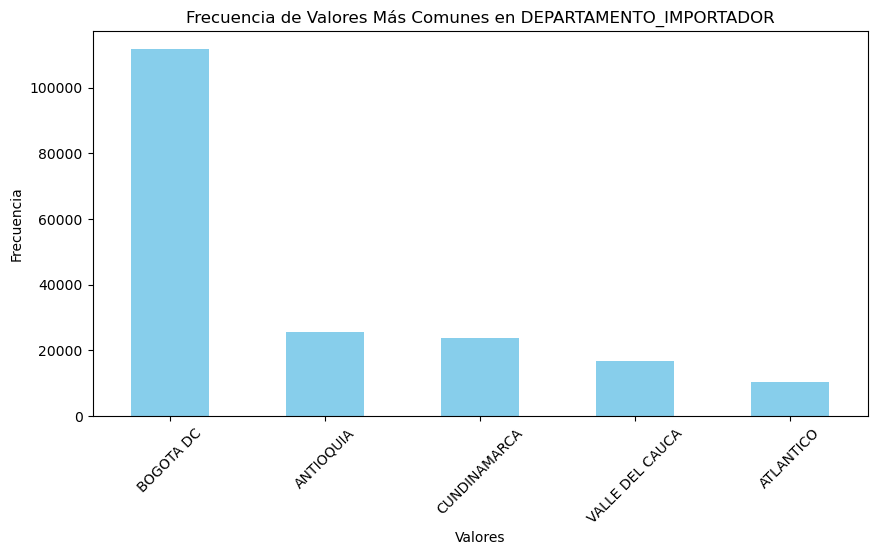

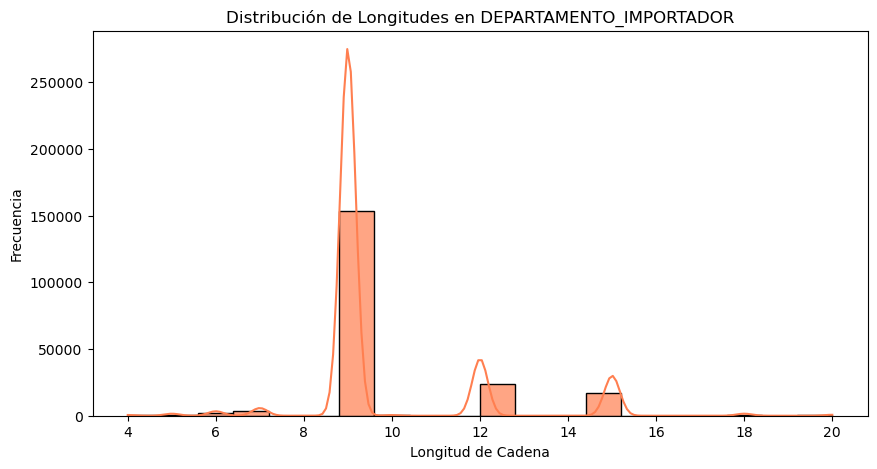


--- Análisis para: DIRECCION_IMPORTADOR ---
Valores únicos: 11036
Valores nulos: 2229 (1.10%)
Duplicados: 190818
Frecuencia de valores más comunes:
DIRECCION_IMPORTADOR
A C 147   58 C   95                        8181
BG  GUADALETE VDA FUSCA AUT NORTE KM 21    3687
CL 72   10   07 OF 1302                    3212
AV AMERICAS  42 A     21                   2430
BG GUADALETE VDA FUSCA AUT NORTE KM 21     2336
Name: count, dtype: int64


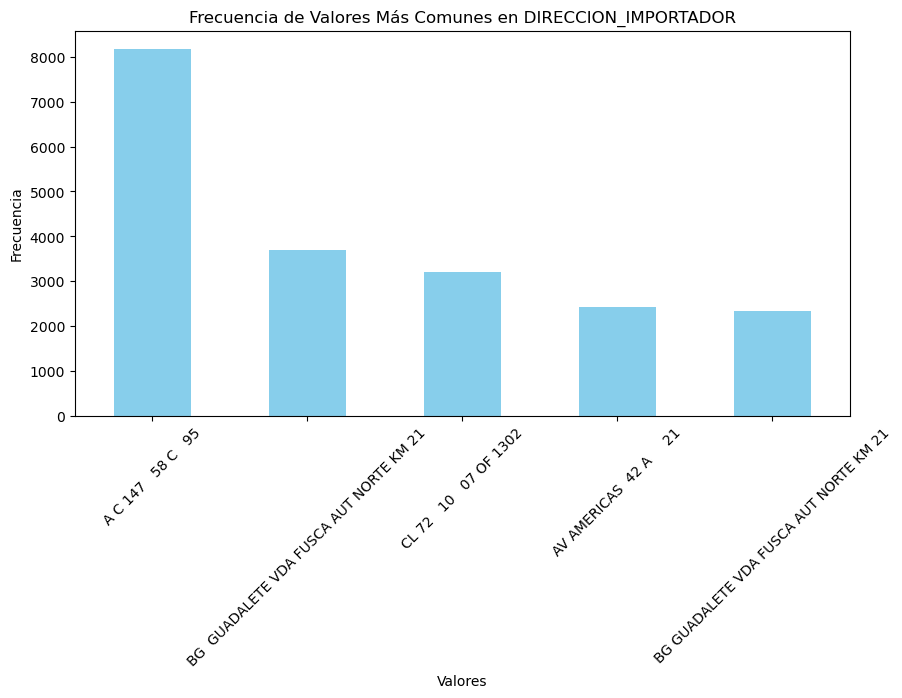

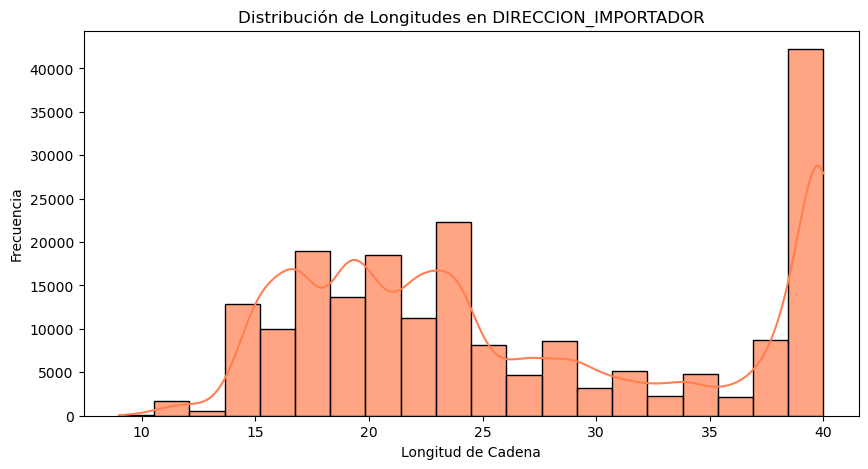

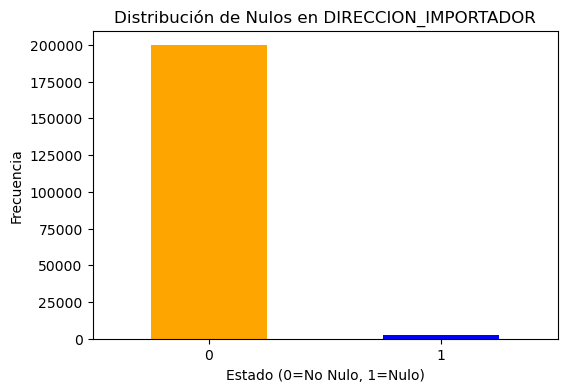


--- Análisis para: DIRECCION_EXPORTADOR ---
Valores únicos: 28618
Valores nulos: 191 (0.09%)
Duplicados: 173236
Frecuencia de valores más comunes:
DIRECCION_EXPORTADOR
230, STADIUM BOULEVARD, SINGAPORE      8181
AVDA. DE LA DIPUTACION - EDIFICIO I    7092
1983 NW 88TH COURT SUITE 301 MIAMI,    3709
Av. Balboa, Edificio PH Art & Yoo,     1850
LAURO PINTO TOLEDO 410 - CABREÚVA      1709
Name: count, dtype: int64


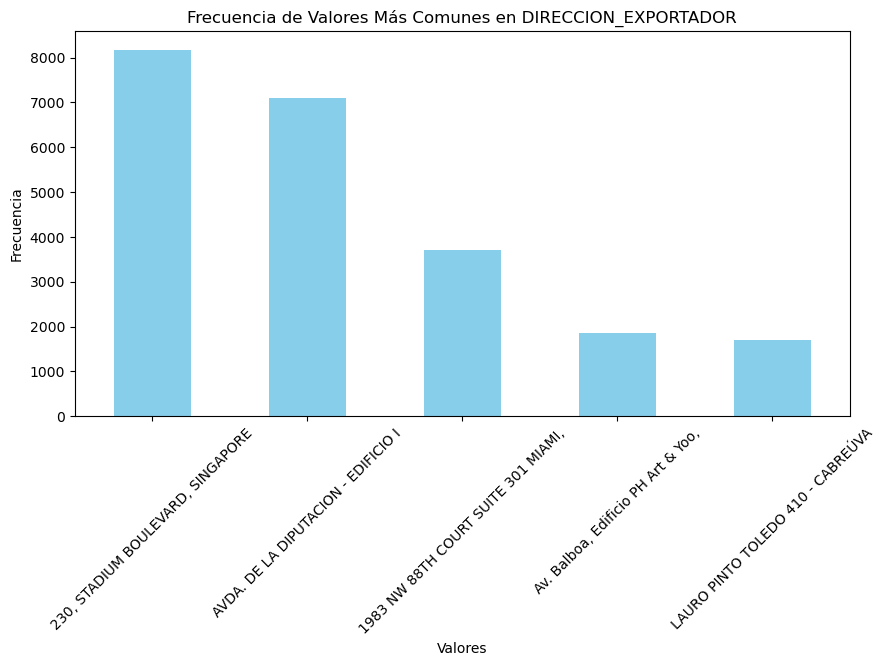

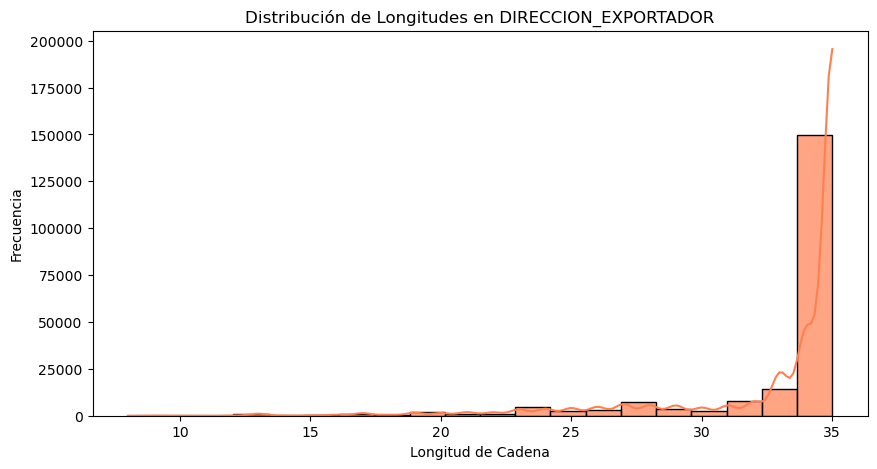

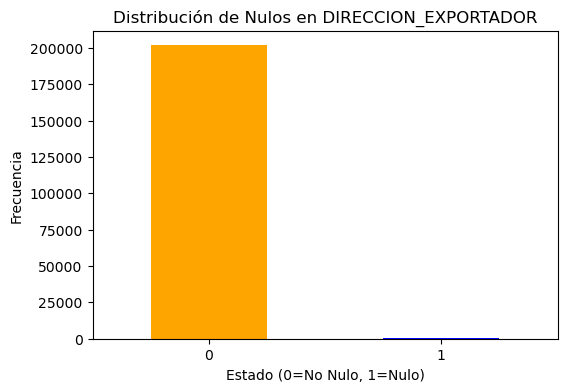


=== ANÁLISIS DE PATRONES Y ANOMALÍAS ===


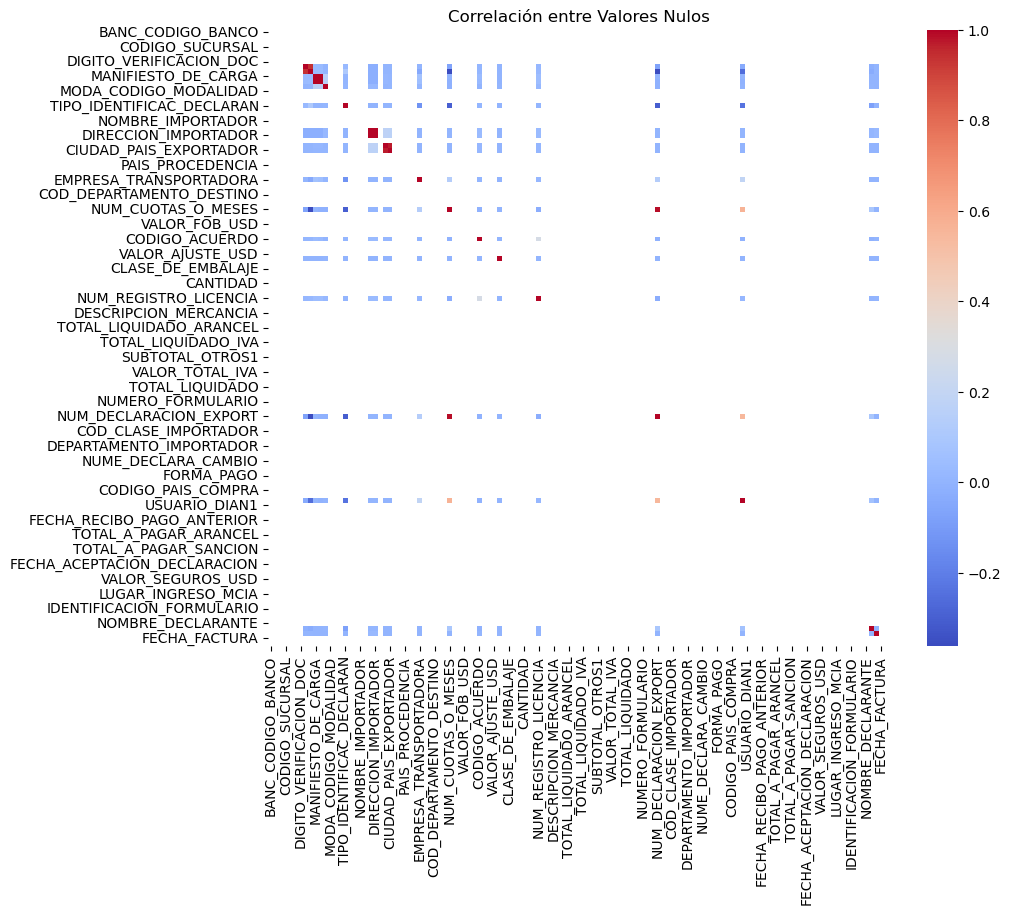

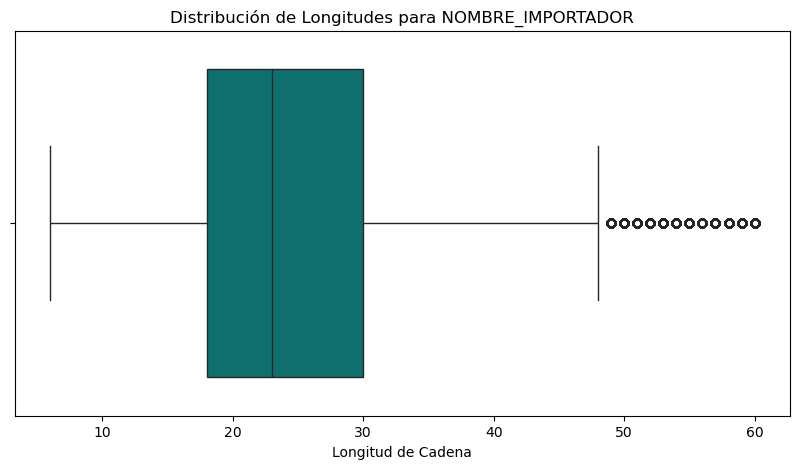

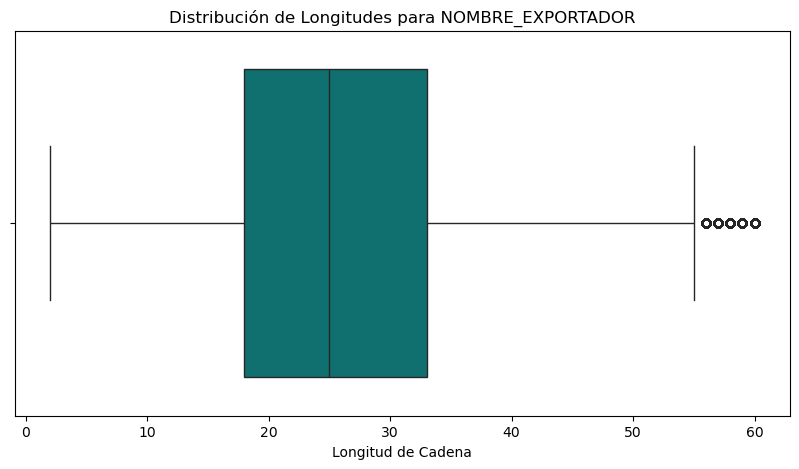

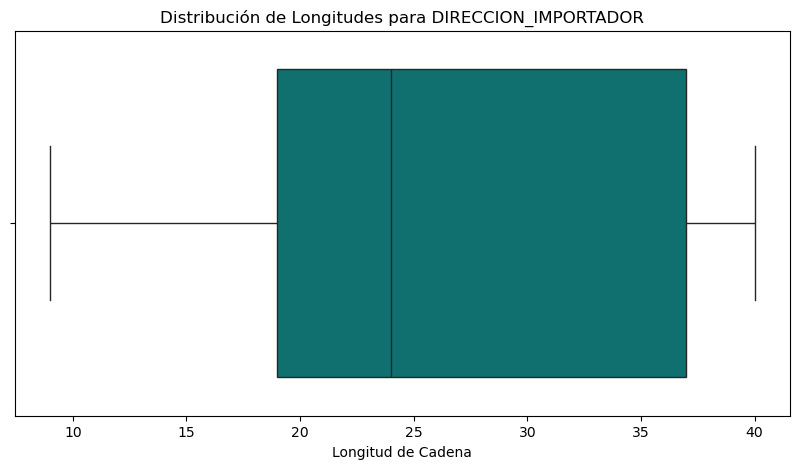

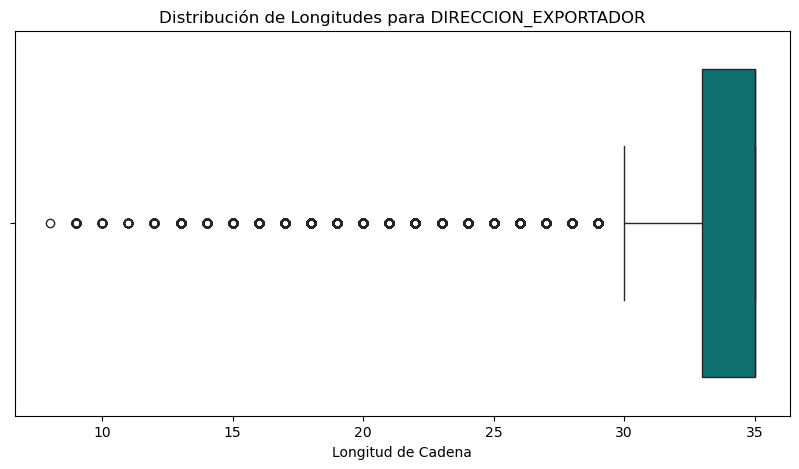


=== Análisis de Valores Atípicos ===
Valores atípicos en NOMBRE_IMPORTADOR: 12401 encontrados
Valores atípicos en NOMBRE_EXPORTADOR: 1435 encontrados
Valores atípicos en DIRECCION_IMPORTADOR: 0 encontrados
Valores atípicos en DIRECCION_EXPORTADOR: 27156 encontrados


In [157]:
df = load_and_examine_data(file_path)
# Mostrar estadísticas descriptivas solo para las columnas relevantes
relevant_columns = [
    'TASA_CAMBIO', 'PESO_NETO', 'VALOR_FOB_USD', 'PESO_BRUTO',
    'FLETES_SEGUROS1', 'VALOR_AJUSTE_USD', 'VALOR_ADUANA_USD',
    'PORCENTAJE_ARANCEL', 'BASE_ARANCEL', 'TOTAL_LIQUIDADO_ARANCEL',
    'PORCENTAJE_IVA', 'BASE_IVA', 'TOTAL_LIQUIDADO_IVA',
    'VALOR_TOTAL_ARANCEL', 'VALOR_TOTAL_IVA', 'VALOR_TOTAL_OTROS',
    'TOTAL_LIQUIDADO_SANCION', 'TOTAL_LIQUIDADO', 'PAGO_TOTAL',
    'VALOR_PAGOS_ANTERIORES', 'TOTAL_A_PAGAR_ARANCEL', 'TOTAL_A_PAGAR_IVA',
    'OTROS_PAGADOS', 'TOTAL_A_PAGAR_SANCION', 'VALOR_CUOTA_USD',
    'VALOR_SEGUROS_USD', 'VALOR_FLETES_USD', 'VALOR_OTROS_GASTOS_USD',
    'VALOR_CIF_USD'
]
for col in df.columns:
    if col not in relevant_columns:
        df[col] = df[col].astype('object')
print("\n=== Estadísticas Descriptivas de Columnas Relevantes ===")
print(df[relevant_columns].describe())
print("\n=== Primeros Registros ===")
print(df.head())
print("\n=== Últimos Registros ===")
print(df.tail())

# 2. Analizar campos de entidades
entity_stats = analyze_entity_fields(df)

# 3. Analizar patrones
patterns = analyze_patterns(df)

### **Bloque 2: Desarrollo de Algoritmo de Matching**

Desarrolla un algoritmo que pueda identificar cuando dos nombres de empresa se refieren
a la misma entidad, considerando:
- Variaciones en el orden de las palabras
- Errores tipográficos comunes
- Abreviaciones y acrónimos
- Diferentes formatos legales (S.A., LTDA, etc.)

Requerimientos:
1. Implementa al menos dos métodos diferentes de matching
2. Evalúa y compara su efectividad
3. Propón una métrica para medir la calidad del matching
4. Documenta los casos edge que identificaste

In [159]:
def normalize_company_name(name):
    """
    Normalizar el nombre de una empresa eliminando formatos legales, puntuación, espacios adicionales,
    considerando variaciones en el orden de palabras, errores tipográficos y abreviaciones.
    """
    if not isinstance(name, str):
        return ""
    name = unidecode(name.upper())  # Eliminar acentos y convertir a mayúsculas
    
    # Eliminación de puntuación y caracteres especiales
    for char in [",", ".", ";", ":", "(", ")", "-", "&", "/"]:
        name = name.replace(char, " ")

    # Reemplazos comunes de formatos legales y abreviaciones
    replacements = {
        " S A ": " ", " LTDA ": " ", " S A S ": " ", " LTD ": " LIMITED ", " LLC ": " ", " CORP ": "  ", "CORPORATION":" ", 
        " CO ": "  "," COMPANY ": " ", " INC ": "  ","INCORPORATED ": " ", " INTL ": "   "," INTERNATIONAL ": " "
    }
    for key, value in replacements.items():
        name = name.replace(key, value)
    
    # Corrección de errores tipográficos comunes y sinónimos
    typo_corrections = {
        "INTERNACIONAL": "INTL",
        "TECHNOLOGY": "TECH"
    }
    for typo, correct in typo_corrections.items():
        name = name.replace(typo, correct)

    # Eliminación de palabras irrelevantes en español e inglés
    stop_words = set(stopwords.words('english') + stopwords.words('spanish'))
    name_tokens = word_tokenize(name)
    name = ' '.join(word for word in name_tokens if word.lower() not in stop_words)
    
    # Ordenar palabras alfabéticamente para evitar diferencias por orden
    name = ' '.join(sorted(name.split()))
    return name.strip()

Algoritmo basado en el match de secuencias, el cuál entrega un score de similaridad.

In [161]:
def match_companies_sequence(name1, name2, threshold=0.85):
    norm_name1 = normalize_company_name(name1)
    norm_name2 = normalize_company_name(name2)
    similarity = SequenceMatcher(None, norm_name1, norm_name2).ratio()
    return similarity >= threshold

Algoritmo basado en la distacnia de Levenshtein, además de ordenamiento avanzado de carácteres.

In [164]:
def match_companies_fuzzywuzzy(name1, name2, threshold=85):
    score = fuzz.token_sort_ratio(normalize_company_name(name1), normalize_company_name(name2))
    return score >= threshold

ALgoritmo basado en Procesamiento de Lenguaje Natural y similaridad de componentes.

In [185]:
def match_companies_spacy(name1, name2, threshold=0.85):
    doc1 = nlp(normalize_company_name(name1))
    doc2 = nlp(normalize_company_name(name2))
    return doc1.similarity(doc2) >= threshold

Algoritmo que se encarga de transformar secuencias basado en un modelo pre-entrenado de embeddings.

In [175]:
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

def match_companies_sentence_transformers(name1, name2, threshold=0.85):
    name1_embed = model.encode(normalize_company_name(name1))
    name2_embed = model.encode(normalize_company_name(name2))
    similarity = util.cos_sim(name1_embed, name2_embed).item()
    return similarity >= threshold

Algoritmo basado en BERT, que usa tokenización de secuencias y un modelo preentrenado para diferentes idiomas, además calcula la similaridad de las secuencias usando la similaridad del coseno funcional.

In [123]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model_bert = BertModel.from_pretrained('bert-base-multilingual-cased')

def match_companies_bert(name1, name2, threshold=0.85):
    inputs = tokenizer([normalize_company_name(name1), normalize_company_name(name2)], return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        embeddings = model_bert(**inputs).last_hidden_state.mean(dim=1)
    similarity = torch.nn.functional.cosine_similarity(embeddings[0], embeddings[1], dim=0).item()
    return similarity >= threshold


Aplicación y evaluación de los diferentes algoritmos entrenados y creados, basado en una muestra de una gran cantidad de compañías de ejemplo, que deberian matchear entre sí.


=== Resultados de Comparación de Modelos ===
                       Empresa 1                     Empresa 2  \
0               BANCOLOMBIA S.A.                BANCOLOMBIA SA   
1                    GRUPO ÉXITO                  GRUPO EXITTO   
2                 ECOPETROL S.A.                  ECOPETROL SA   
3    ISA INTERCONEXIÓN ELÉCTRICA  INTERCONEXION ELECTRICA S.A.   
4               ALPINA PRODUCTOS                        ALPINA   
..                           ...                           ...   
207            CIGNA CORPORATION                         CIGNA   
208           SUN LIFE FINANCIAL                       SUNLIFE   
209                NEW YORK LIFE       NEW YORK LIFE INSURANCE   
210  NATIONWIDE MUTUAL INSURANCE                    NATIONWIDE   
211               LIBERTY MUTUAL             LIBERTY INSURANCE   

    SequenceMatcher FuzzyWuzzy     Spacy Sentence Transformer      Bert  
0             MATCH      MATCH  NO MATCH                MATCH     MATCH  
1            

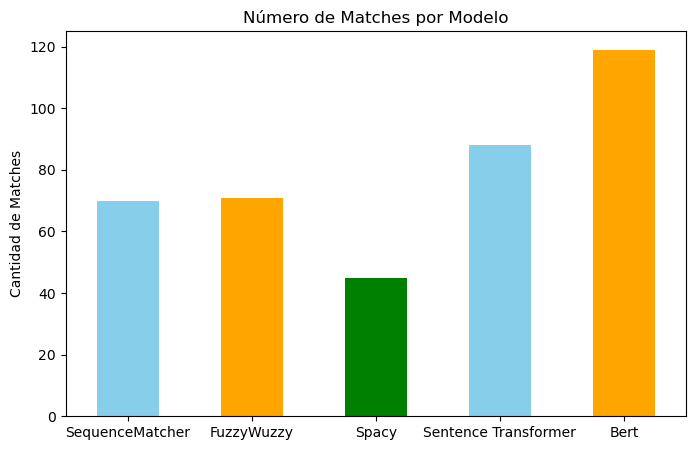

In [189]:
examples = [
    # Empresas Colombianas
    ("BANCOLOMBIA S.A.", "BANCOLOMBIA SA"),
    ("GRUPO ÉXITO", "GRUPO EXITTO"),
    ("ECOPETROL S.A.", "ECOPETROL SA"),
    ("ISA INTERCONEXIÓN ELÉCTRICA", "INTERCONEXION ELECTRICA S.A."),
    ("ALPINA PRODUCTOS", "ALPINA"),
    ("GRUPO AVAL", "GRUPO AVAAL"),
    ("CARVAJAL S.A.", "CARBAJAL S.A."),
    ("NUTRESA S.A.", "GRUPO NUTRESA"),
    ("POSTOBÓN S.A.", "POSTOBON"),
    ("AVIANCA HOLDINGS", "AVIANCA S.A."),
    ("ETB", "EMPRESA DE TELECOMUNICACIONES DE BOGOTA"),
    ("COLOMBINA S.A.", "COLOMBINA SA"),
    ("PAVCO COLOMBIA", "PAVCO S.A."),
    ("FALABELLA COLOMBIA", "FALABELA"),
    ("CEMEX COLOMBIA", "CEMMEX COLOMBIA"),
    ("TIGO UNE", "UNE TELECOMUNICACIONES"),
    ("CÁLIDDA GAS", "CALIDA GAS"),
    ("BAVARIA S.A.", "BAVARIA"),
    ("GRUPO ARGOS", "ARGOS GROUP"),
    ("RAPI COLOMBIA", "RAPPI COLOMBIA"),
    ("GOOGLE LLC", "GOOGLE INCORPORATED"),
    ("MICROSOFT CORPORATION", "MICROSOFT CORP"),
    ("APPLE INC.", "APPLE INTERNATIONAL"),
    ("FACEBOOK INC", "META PLATFORMS"),
    ("AMAZON.COM INC", "AMAZON INC"),
    ("TESLA MOTORS", "TESLA INC"),
    ("SAMSUNG ELECTRONICS", "SAMSUMG ELECTRONICS"),
    ("SONY CORPORATION", "SONY INC"),
    ("TOYOTA MOTOR CORPORATION", "TOYOTA MOTORS"),
    ("FORD MOTOR COMPANY", "FORD MOTORS"),
    ("GENERAL MOTORS", "GENERAL MOTORES"),
    ("VOLKSWAGEN GROUP", "VOLKSWAGEN AG"),
    ("HYUNDAI MOTOR COMPANY", "HYUNDAI MOTORS"),
    ("IBM CORPORATION", "INTERNATIONAL BUSINESS MACHINES"),
    ("ADOBE SYSTEMS INC.", "ADOBE INC"),
    ("ORACLE CORPORATION", "ORACLE CORP"),
    ("DELL TECHNOLOGIES", "DELL INC"),
    ("HEWLETT PACKARD ENTERPRISE", "HP INC"),
    ("NVIDIA CORPORATION", "NVIDIA INC"),
    ("INTEL CORPORATION", "INTEL CORP"),
    ("GOOGLE LLC", "GOGLE INC"),
    ("COCA COLA", "COCA-COLA"),
    ("COCA-COLA", "COCA COLA COMPANY"),
    ("PEPSICO INC.", "PEPSI CO"),
    ("FORD MOTORS", "FORD_MOTORS"),
    ("NESTLE S.A.", "NESTLÉ S.A."),
    ("PROCTER AND GAMBLE", "PROCTER & GAMBLE"),
    ("JOHNSON & JOHNSON", "J&J"),
    ("L'OREAL SA", "LOREAL SA"),
    ("ESTEE LAUDER", "ESTEE LAUDR"),
    ("REDBULL GMBH", "RED BULL"),
    ("NIKE INC", "NAIKE INC"),
    ("ADIDAS AG", "ADYDAS AG"),
    ("PUMA SE", "PUMMA SE"),
    ("REEBOK INTERNATIONAL", "REEBOOK INTERNATIONAL"),
    ("TESLA MOTORS", "TESLAA INC"),
    ("SPACEX", "SPACE-X"),
    ("FACEBOOK INC", "FACBOOK INC"),
    ("BANCO SANTANDER", "SANTANDER BANK"),
    ("BBVA BANCOLOMBIA", "BANCO BBVA"),
    ("CITIBANK N.A.", "CITI BANK"),
    ("HSBC HOLDINGS PLC", "HSBC BANK"),
    ("JP MORGAN CHASE", "JPMORGAN"),
    ("GOLDMAN SACHS", "GOLDMAN SAKS"),
    ("BANK OF AMERICA", "BANK AMERICA"),
    ("DEUTSCHE BANK AG", "DEUTSCHE BANK"),
    ("MORGAN STANLEY", "MORGAN STANLY"),
    ("CREDIT SUISSE", "CREDIT SWISS"),
    ("ERICSSON", "ERICSSON TELECOM"),
    ("NOKIA CORPORATION", "NOKIA INC"),
    ("VODAFONE GROUP", "VODAFONE PLC"),
    ("AT&T INC", "ATT INC"),
    ("VERIZON COMMUNICATIONS", "VERIZON INC"),
    ("T-MOBILE USA", "TMOBILE"),
    ("CHINA MOBILE", "CHINA MOBILE LIMITED"),
    ("HUAWEI TECHNOLOGIES", "HUAWEI TECH"),
    ("XIAOMI CORPORATION", "XIAOMI INC"),
    ("LG ELECTRONICS", "LG ELECTRONIC"),
    ("DELTA AIR LINES", "DELTA AIRLINES"),
    ("AMERICAN AIRLINES", "AMERICAN AIRLINE"),
    ("UNITED AIRLINES", "UNITED INC"),
    ("EMIRATES AIRLINE", "EMIRATES"),
    ("AIR FRANCE-KLM", "AIR FRANCE"),
    ("LUFTHANSA GROUP", "LUFTHANSA"),
    ("BRITISH AIRWAYS", "BA"),
    ("TURKISH AIRLINES", "TURKISH"),
    ("QATAR AIRWAYS", "QATAR"),
    ("LATAM AIRLINES", "LATAM"),
    ("PHILIPS ELECTRONICS", "PHILIPS"),
    ("PANASONIC CORP", "PANASONIK CORP"),
    ("CISCO SYSTEMS INC", "CISCO"),
    ("DELL TECHNOLOGIES", "DELL INC"),
    ("GENERAL ELECTRIC", "GE"),
    ("ROLLS-ROYCE", "ROLLS ROYS"),
    ("LOCKHEED MARTIN", "LOCKHEAD MARTIN"),
    ("AIRBUS SE", "AIRBUS"),
    ("HONEYWELL INTERNATIONAL", "HONEY WELL INTERNATIONAL"),
    ("GE AVIATION", "GE AVIATION"),
    ("REDBULL GMBH", "RED BULL"),
    ("TOYOTA MOTOR", "TOYOTA MOTORS"),
    ("FORD INC", "FORD MOTOR COMPANY"),
    ("NIKE", "NAIKE INC"),
    ("ADIDAS", "ADYDAS INC"),
    ("HP INC", "HEWLETT PACKARD"),
    ("SPOTIFY TECHNOLOGY", "SPOTIFY INC"),
    ("NETFLIX INC", "NETFLICKS INC"),
    ("SICEX S.A.S", "SECIZ LTDA."),
    ("SURAMERICA COMERCIAL S.A.S ","SUDAMERIC COMERCIO SAS"),
    ("GENERAL DE EQUIPOS DE COLOMBIA S A GECOLSA ","GECOLSA S.A."),
    ("DRUMMOND LTD","DRUMON"),
    ("COMPAnIA DE INVERSIONES TEXTILES DE MODA S.A.S. - TEXMODA S.","TEXMODA S.A.S"),
    ("DECATHLON COLOMBIA SAS  ","DEchaTLON sas"),
    ("EXXON MOBIL CORPORATION", "EXXON MOBIL CORP"),
    ("ROYAL DUTCH SHELL", "SHELL PLC"),
    ("BP PLC", "BRITISH PETROLEUM"),
    ("CHEVRON CORPORATION", "CHEVRON CORP"),
    ("TOTALENERGIES SE", "TOTAL SE"),
    ("PETROBRAS", "PETROLEO BRASILEIRO S.A."),
    ("REPSOL S.A.", "REPSOL SA"),
    ("GAZPROM", "GAZ PROM"),
    ("ROSNEFT OIL COMPANY", "ROSNEFT"),
    ("EQUINOR ASA", "STATOIL ASA"),
    ("PFIZER INC.", "PFIZER"),
    ("MODERNA INC.", "MODERNA"),
    ("ASTRAZENECA PLC", "ASTRA ZENECA"),
    ("GSK PLC", "GLAXOSMITHKLINE"),
    ("SANOFI S.A.", "SANOFI"),
    ("BAYER AG", "BAYER HEALTHCARE"),
    ("NOVARTIS AG", "NOVARTIS"),
    ("ABBVIE INC.", "ABBVIE PHARMA"),
    ("ELI LILLY AND COMPANY", "ELI LILLY"),
    ("BRISTOL-MYERS SQUIBB", "BMS"),
    ("VOTORANTIM CIMENTOS", "VOTORANTIM"),
    ("HOLCIM LTD", "LAFARGE HOLCIM"),
    ("CEMEX SAB DE CV", "CEMEX"),
    ("CRH PLC", "CRH CEMENT"),
    ("CHINA NATIONAL BUILDING MATERIAL", "CNBM"),
    ("SAINT-GOBAIN", "SAINT GOBAIN"),
    ("VULCAN MATERIALS COMPANY", "VULCAN MATERIALS"),
    ("MARTIN MARIETTA MATERIALS", "MARTIN MARIETTA"),
    ("HEIDELBERGCEMENT AG", "HEIDELBERG CEMENT"),
    ("BBMG CORPORATION", "BBMG CORP"),
    ("AMERICA MOVIL", "AMERICA MOVIL S.A.B."),
    ("TELEFONICA S.A.", "TELEFONICA"),
    ("CHINA TELECOM", "CHINA TELECOM LTD"),
    ("NIPPON TELEGRAPH AND TELEPHONE", "NTT"),
    ("KDDI CORPORATION", "KDDI"),
    ("VIVENDI", "VIVENDI TELECOM"),
    ("ORANGE S.A.", "ORANGE TELECOM"),
    ("TELEKOM MALAYSIA", "TELEKOM MY"),
    ("SINGAPORE TELECOM", "SINGTEL"),
    ("TELSTRA CORPORATION", "TELSTRA"),
    ("DANONE S.A.", "DANONE"),
    ("KRAFT HEINZ", "KRAFTHEINZ"),
    ("GENERAL MILLS", "GEN MILLS"),
    ("KELLOGG'S", "KELLOGG"),
    ("MARS INC.", "MARS"),
    ("HERSHEY'S", "HERSHEY CO"),
    ("NABISCO", "NABISCO INC."),
    ("CAMPBELL SOUP COMPANY", "CAMPBELL"),
    ("TYSON FOODS", "TYSON INC."),
    ("CONAGRA BRANDS", "CONAGRA"),
    ("FEDEX CORPORATION", "FEDEX"),
    ("UPS INC.", "UNITED PARCEL SERVICE"),
    ("DHL GROUP", "DEUTSCHE POST DHL"),
    ("MAERSK LINE", "MAERSK"),
    ("CMA CGM", "CMA CGM GROUP"),
    ("COSCO SHIPPING", "COSCO"),
    ("MSC MEDITERRANEAN SHIPPING", "MSC"),
    ("NIPPON EXPRESS", "NIPPON EXPRESS LTD"),
    ("KUEHNE + NAGEL", "KUEHNE NAGEL"),
    ("SCHENKER AG", "DB SCHENKER"),
    ("CHANEL S.A.", "CHANEL"),
    ("LOUIS VUITTON", "LVMH"),
    ("HERMES INTERNATIONAL", "HERMES"),
    ("PRADA S.P.A.", "PRADA"),
    ("FENDI", "FENDI ITALIA"),
    ("VERSACE", "GIANNI VERSACE"),
    ("RALPH LAUREN CORPORATION", "RALPH LAUREN"),
    ("BURBERRY GROUP PLC", "BURBERRY"),
    ("DOLCE & GABBANA", "DOLCE GABBANA"),
    ("GUCCI", "GUCCI SPA"),
    ("SAP SE", "SAP"),
    ("SALESFORCE INC.", "SALESFORCE"),
    ("ADOBE INC.", "ADOBE SYSTEMS"),
    ("ORACLE CORPORATION", "ORACLE"),
    ("INTUIT INC.", "INTUIT"),
    ("AUTODESK INC.", "AUTODESK"),
    ("SERVICE NOW", "SERVICENOW"),
    ("VMWARE INC.", "VMWARE"),
    ("CISCO SYSTEMS", "CISCO"),
    ("SNOWFLAKE INC.", "SNOWFLAKE"),
    ("MARRIOTT INTERNATIONAL", "MARRIOTT HOTELS"),
    ("HILTON HOTELS & RESORTS", "HILTON"),
    ("HYATT HOTELS CORPORATION", "HYATT"),
    ("INTERCONTINENTAL HOTELS GROUP", "IHG"),
    ("WYNDHAM HOTELS & RESORTS", "WYNDHAM"),
    ("ACCOR HOTELS", "ACCOR SA"),
    ("CHOICE HOTELS INTERNATIONAL", "CHOICE HOTELS"),
    ("RADISSON HOTEL GROUP", "RADISSON"),
    ("BEST WESTERN HOTELS", "BEST WESTERN"),
    ("FOUR SEASONS HOTELS", "FOUR SEASONS"),
    ("AXA GROUP", "AXA INSURANCE"),
    ("ALLIANZ SE", "ALLIANZ"),
    ("METLIFE INC.", "MET LIFE"),
    ("PRUDENTIAL FINANCIAL", "PRUDENTIAL"),
    ("AIG - AMERICAN INTERNATIONAL GROUP", "AIG"),
    ("CIGNA CORPORATION", "CIGNA"),
    ("SUN LIFE FINANCIAL", "SUNLIFE"),
    ("NEW YORK LIFE", "NEW YORK LIFE INSURANCE"),
    ("NATIONWIDE MUTUAL INSURANCE", "NATIONWIDE"),
    ("LIBERTY MUTUAL", "LIBERTY INSURANCE"),
]


# Evaluate models
results = []
for name1, name2 in examples:
    seq_match = match_companies_sequence(name1, name2)
    fuzzy_match = match_companies_fuzzywuzzy(name1, name2)
    spacy_match = match_companies_spacy(name1, name2)
    sentence_transformer_match = match_companies_sentence_transformers(name1, name2)
    bert_match = match_companies_bert(name1, name2)
                                                                       
    
    results.append({
        "Empresa 1": name1,
        "Empresa 2": name2,
        "SequenceMatcher": "MATCH" if seq_match else "NO MATCH",
        "FuzzyWuzzy": "MATCH" if fuzzy_match else "NO MATCH",
        "Spacy": "MATCH" if spacy_match else "NO MATCH",
        "Sentence Transformer": "MATCH" if sentence_transformer_match else "NO MATCH",
        "Bert": "MATCH" if bert_match else "NO MATCH"
})

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Count matches per model
match_counts = df_results.apply(lambda x: (x == "MATCH").sum(), axis=0)
match_counts.drop(["Empresa 1", "Empresa 2"], inplace=True)

# Mostrar la tabla de resultados de coincidencias
print("\n=== Resultados de Comparación de Modelos ===")
print(df_results)

# Mostrar el conteo de coincidencias por modelo
print("\n=== Conteo de Matches por Modelo ===")
print(match_counts)

# Visualización de conteo de coincidencias por modelo
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
match_counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title("Número de Matches por Modelo")
plt.ylabel("Cantidad de Matches")
plt.xticks(rotation=0)
plt.show()

Se presenta además un análisis de casos contrarios, en el que los algoritmos no deberían MATCHEAR las compañías porque no son las mismas.


=== Resultados de Comparación de Modelos en Negativos ===
                   Empresa 1                    Empresa 2 SequenceMatcher  \
0           BANCOLOMBIA S.A.                  GRUPO ÉXITO        NO MATCH   
1             ECOPETROL S.A.  ISA INTERCONEXIÓN ELÉCTRICA        NO MATCH   
2           ALPINA PRODUCTOS                POSTOBÓN S.A.        NO MATCH   
3                 GRUPO AVAL             AVIANCA HOLDINGS        NO MATCH   
4              CARVAJAL S.A.               COLOMBINA S.A.        NO MATCH   
5         FALABELLA COLOMBIA                     TIGO UNE        NO MATCH   
6             CEMEX COLOMBIA                 BAVARIA S.A.        NO MATCH   
7                 GOOGLE LLC        MICROSOFT CORPORATION        NO MATCH   
8                 APPLE INC.                 FACEBOOK INC        NO MATCH   
9             AMAZON.COM INC                 TESLA MOTORS        NO MATCH   
10       SAMSUNG ELECTRONICS              IBM CORPORATION        NO MATCH   
11          SONY 

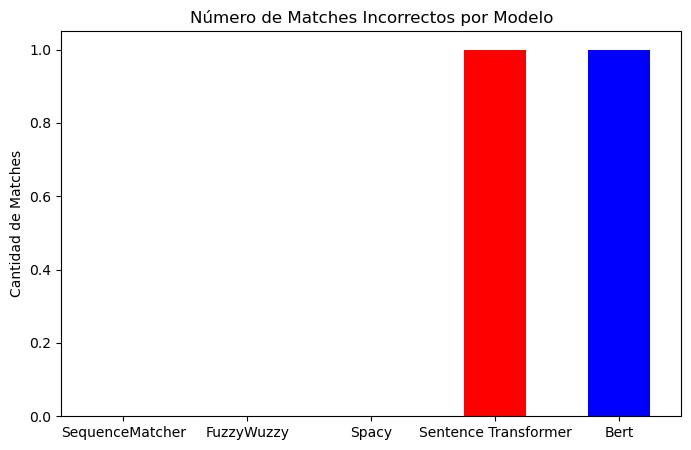

In [196]:
negative_examples = [
    ("BANCOLOMBIA S.A.", "GRUPO ÉXITO"),
    ("ECOPETROL S.A.", "ISA INTERCONEXIÓN ELÉCTRICA"),
    ("ALPINA PRODUCTOS", "POSTOBÓN S.A."),
    ("GRUPO AVAL", "AVIANCA HOLDINGS"),
    ("CARVAJAL S.A.", "COLOMBINA S.A."),
    ("FALABELLA COLOMBIA", "TIGO UNE"),
    ("CEMEX COLOMBIA", "BAVARIA S.A."),
    ("GOOGLE LLC", "MICROSOFT CORPORATION"),
    ("APPLE INC.", "FACEBOOK INC"),
    ("AMAZON.COM INC", "TESLA MOTORS"),
    ("SAMSUNG ELECTRONICS", "IBM CORPORATION"),
    ("SONY CORPORATION", "DELL TECHNOLOGIES"),
    ("TOYOTA MOTOR CORPORATION", "VOLKSWAGEN GROUP"),
    ("HYUNDAI MOTOR COMPANY", "GENERAL MOTORS"),
    ("ADOBE SYSTEMS INC.", "NVIDIA CORPORATION"),
    ("COCA COLA", "PEPSICO INC."),
    ("FORD MOTORS", "TESLA INC"),
    ("NESTLE S.A.", "KRAFT HEINZ"),
    ("PROCTER AND GAMBLE", "UNILEVER PLC"),
    ("BANCO SANTANDER", "GOOGLE LLC"),
    ("BBVA BANCOLOMBIA", "MICROSOFT CORPORATION"),
    ("CITIBANK N.A.", "TESLA MOTORS"),
    ("HSBC HOLDINGS PLC", "COCA-COLA COMPANY"),
    ("JP MORGAN CHASE", "NIKE INC"),
    ("GOLDMAN SACHS", "AIRBUS SE"),
    ("BANK OF AMERICA", "ADOBE SYSTEMS INC."),
    ("DEUTSCHE BANK AG", "APPLE INC."),
    ("MORGAN STANLEY", "META PLATFORMS"),
    ("CREDIT SUISSE", "DELL TECHNOLOGIES"),
    ("DELTA AIR LINES", "XIAOMI CORPORATION"),
    ("AMERICAN AIRLINES", "LG ELECTRONICS"),
    ("UNITED AIRLINES", "VODAFONE GROUP"),
    ("EMIRATES AIRLINE", "AT&T INC"),
    ("AIR FRANCE-KLM", "HUAWEI TECHNOLOGIES"),
    ("LUFTHANSA GROUP", "SPOTIFY TECHNOLOGY"),
    ("BRITISH AIRWAYS", "NETFLIX INC"),
    ("TURKISH AIRLINES", "RED BULL"),
    ("QATAR AIRWAYS", "CISCO SYSTEMS INC"),
    ("LATAM AIRLINES", "FORD MOTOR COMPANY"),
    ("DISNEY", "DISCOVERY CHANNEL"),
    ("TWITTER", "TWITCH"),
    ("TIKTOK", "SNAPCHAT"),
    ("ALIBABA", "ALIEXPRESS"),
    ("SHEIN", "ZARA"),
    ("UBER", "LYFT"),
    ("TINDER", "BUMBLE"),
    ("SPOTIFY", "DEEZER"),
    ("YOUTUBE", "VIMEO"),
    ("HP INC", "HONDA MOTOR CO."),
    ("IBM CORPORATION", "IKEA"),
    ("GOOGLE LLC", "GOODLE"),
    ("META PLATFORMS", "METAL INC."),
    ("MICROSOFT CORP", "MICROSOTF"),
    ("NIKE INC", "NICKELODEON INC"),
    ("APPLE INC.", "APLEFAL SA"),
    ("TESLA MOTORS", "ELLA AMOTORS"),
    ("AIRBNB", "AIR JORDAN"),
]

# Evaluación de modelos con ejemplos negativos
results_negative = []
for name1, name2 in negative_examples:
    seq_match = match_companies_sequence(name1, name2)
    fuzzy_match = match_companies_fuzzywuzzy(name1, name2)
    spacy_match = match_companies_spacy(name1, name2)
    sentence_transformer_match = match_companies_sentence_transformers(name1, name2)
    bert_match = match_companies_bert(name1, name2)
    
    results_negative.append({
        "Empresa 1": name1,
        "Empresa 2": name2,
        "SequenceMatcher": "MATCH" if seq_match else "NO MATCH",
        "FuzzyWuzzy": "MATCH" if fuzzy_match else "NO MATCH",
        "Spacy": "MATCH" if spacy_match else "NO MATCH",
        "Sentence Transformer": "MATCH" if sentence_transformer_match else "NO MATCH",
        "Bert": "MATCH" if bert_match else "NO MATCH"
    })

# Convert results to DataFrame
df_results_negative = pd.DataFrame(results_negative)

# Count matches per model
match_counts_negative = df_results_negative.apply(lambda x: (x == "MATCH").sum(), axis=0)
match_counts_negative.drop(["Empresa 1", "Empresa 2"], inplace=True)

# Mostrar la tabla de resultados de coincidencias
print("\n=== Resultados de Comparación de Modelos en Negativos ===")
print(df_results_negative)

# Mostrar el conteo de coincidencias por modelo
print("\n=== Conteo de Matches en Negativos por Modelo ===")
print(match_counts_negative)

# Visualización de conteo de coincidencias por modelo
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
match_counts_negative.plot(kind='bar', color=['red', 'blue', 'green'])
plt.title("Número de Matches Incorrectos por Modelo")
plt.ylabel("Cantidad de Matches")
plt.xticks(rotation=0)
plt.show()


### **Análisis de Resultados de los Algoritmos de Matching**

Se implementaron cinco algoritmos de matching, abarcando desde técnicas tradicionales pero efectivas, como SequenceMatcher, hasta enfoques más avanzados como Sentence Transformer y BERT.

La evaluación de los modelos se realizó en un conjunto de 212 empresas de prueba, diseñado para incluir una variedad de desafíos, como errores tipográficos, abreviaciones y diferencias en los nombres oficiales de las empresas. Estos ejemplos representaron un escenario realista en el que se enfrentaron los modelos a diversos retos.

Se identificaron casos particularmente desafiantes, como empresas con nombres completamente distintos en función de su identidad corporativa (por ejemplo, "Facebook" y "Meta"), así como compañías con nombres oficiales extensos y sus correspondientes abreviaturas (por ejemplo, "International Business Machines" frente a "IBM"). Los errores de tipeo representaron un obstáculo significativo para los modelos de menor rendimiento, mientras que técnicas más avanzadas como BERT y SequenceMatcher demostraron una mayor capacidad para manejarlos con precisión.

Tras un análisis exhaustivo de los resultados obtenidos, considerando el número total de coincidencias correctas (verdaderos positivos) identificadas por cada algoritmo, se concluyó que el modelo basado en BERT mostró el mejor desempeño. Este modelo se destacó por su capacidad para capturar similitudes semánticas complejas, lo que lo convierte en la opción más adecuada para la tarea de matching de nombres de empresas.

Además, se analizó el rendimiento de los modelos utilizando datos de ejemplo que no deberían coincidir. Los resultados demostraron un desempeño sólido en la identificación de falsos positivos en todos los modelos evaluados. Debido a la alta precisión observada en estos casos, los resultados obtenidos en estos escenarios no fueron considerados en la creación de la métrica final de evaluación de los modelos.


### **Bloque 3: Escalabilidad y Optimización (Opcional)**

Ahora que has desarrollado un algoritmo básico, necesitamos escalarlo para procesar
grandes volúmenes de datos eficientemente.

### Tareas:
1. Optimiza tu algoritmo para mejorar su rendimiento
2. Implementa una estrategia para reducir comparaciones innecesarias
3. Propón una estructura de datos eficiente para almacenar los matches
4. Sugiere una arquitectura para procesar actualizaciones incrementales

### **Optimización del algoritmo**
1. Para optimizar el algoritmo, hacemos un refinamiento de nuestra función para normalizar los nombres de las compañías, ahora también permite listas de nombres de compañías, lo que es útil ya que queremos procesar grandes volúmenes de datos.

In [199]:
spanish_stopwords = set(stopwords.words('spanish'))
english_stopwords = set(stopwords.words('english'))

def normalize_company_name(name):
    """
    Normaliza un nombre de empresa eliminando caracteres especiales,
    convirtiendo a minúsculas, eliminando espacios adicionales, 
    y reemplazando abreviaturas comunes.
    """
    if not isinstance(name, str):
        return ""
    
    name = unidecode(name.upper())  
    name = re.sub(r'[^a-z0-9\s]', '', name)  
    name = re.sub(r'\s+', ' ', name).strip()  

    # Reemplazos comunes de formatos legales y abreviaciones
    replacements = {
        " S A ": " ", " LTDA ": " ", " S A S ": " ", " LTD ": " LIMITED ", " LLC ": " ", " CORP ": "  ", "CORPORATION":" ", 
        " CO ": "  "," COMPANY ": " ", " INC ": "  ","INCORPORATED ": " ", " INTL ": "   "," INTERNATIONAL ": " "
    }
    for key, value in replacements.items():
        name = name.replace(key, value)

    # Eliminación de stopwords comunes en español e inglés
    words = name.split()
    name = ' '.join([word for word in words if word not in spanish_stopwords and word not in english_stopwords])

    return name

2. El siguiente paso es generar datos de gran escala para evaluar, además se crean datos para comparar, se crea una gran cantidad de combinaciones para evaluar

In [203]:
import random

large_company_list = [
    "Google LLC", "Alphabet Inc.", "Amazon Inc.", "Microsoft Corp.", "Apple Inc.",
    "Facebook Inc.", "Meta Platforms", "Netflix Inc.", "IBM Corporation", "Oracle Corporation",
    "Intel Corporation", "AMD Inc.", "Tesla Motors", "Adobe Systems Inc.", "HP Inc.",
    "Dell Technologies", "Cisco Systems", "SAP SE", "Samsung Electronics", "Sony Corporation",
    "Nokia Corporation", "Xiaomi Inc.", "LG Electronics", "Huawei Technologies", "Qualcomm Inc.",
    "Twitter Inc.", "Snapchat Inc.", "Spotify Technology", "Dropbox Inc.", "Slack Technologies",
    "Zoom Video Communications", "Alibaba Group", "Tencent Holdings", "TikTok", "Baidu Inc.",
    "AsusTek Computer", "Lenovo Group", "Ericsson", "ZTE Corporation", "Broadcom Inc.",
    "Walmart Inc.", "Target Corporation", "Costco Wholesale", "Best Buy Co.", "Home Depot",
    "Lowe's Companies", "CVS Health", "Walgreens Boots Alliance", "Dollar General",
    "Kroger Company", "Carrefour S.A.", "Tesco PLC", "Aldi Group", "Lidl Stiftung", "7-Eleven",
    "Metro AG", "Auchan Retail", "JCPenney", "Macy's Inc.", "Nordstrom Inc.",
    "IKEA", "Sephora", "H&M Hennes & Mauritz", "Uniqlo", "Gap Inc.", "Nike Inc.", "Adidas AG",
    "Puma SE", "Under Armour", "Reebok International", "FILA Korea", "Decathlon S.A.",
    "Ross Stores", "TJX Companies", "Foot Locker", "Abercrombie & Fitch", "Victoria's Secret",
    "JPMorgan Chase", "Bank of America", "Citibank", "Wells Fargo", "Goldman Sachs",
    "Morgan Stanley", "HSBC Holdings", "Barclays Bank", "BNP Paribas", "Deutsche Bank",
    "Santander Group", "UBS Group", "Credit Suisse", "ING Group", "Scotiabank",
    "Royal Bank of Canada", "Banco Santander", "Bank of China", "BBVA", "Bancolombia",
    "Itaú Unibanco", "Standard Chartered", "American Express", "Visa Inc.", "MasterCard Inc.",
    "BNY Mellon", "PayPal Holdings", "Square Inc.", "Western Union", "Discover Financial Services",
    "Capital One", "Fidelity Investments", "Charles Schwab Corporation", "TD Bank Group",
    "Exxon Mobil Corporation", "Chevron Corporation", "Royal Dutch Shell", "BP PLC", "TotalEnergies SE",
    "Petrobras", "Eni S.p.A.", "ConocoPhillips", "Schlumberger Limited", "Halliburton Company",
    "Baker Hughes", "CNOOC Limited", "Gazprom", "Rosneft", "Repsol S.A.",
    "Ecopetrol S.A.", "Pacific Rubiales Energy", "Engie S.A.", "NextEra Energy", "Duke Energy",
    "Siemens Energy", "Enel S.p.A.", "Dominion Energy", "Southern Company", "Xcel Energy",
    "Chevron Phillips Chemical", "Cheniere Energy", "Sempra Energy", "Williams Companies",
    "Toyota Motor Corporation", "Volkswagen AG", "Ford Motor Company", "Honda Motor Co.", "General Motors",
    "Nissan Motor Co.", "BMW Group", "Mercedes-Benz", "Hyundai Motor Company", "Tesla Inc.",
    "Subaru Corporation", "Ferrari N.V.", "Lamborghini S.p.A.", "Maserati S.p.A.", "Aston Martin",
    "Bugatti Automobiles", "Porsche AG", "Fiat Chrysler Automobiles", "Rolls-Royce Motor Cars", "Volvo Cars",
    "Mitsubishi Motors", "Kia Corporation", "Peugeot S.A.", "Renault Group", "Tata Motors",
    "Mahindra & Mahindra", "Great Wall Motors", "Geely Automobile", "Suzuki Motor Corporation",
    "Johnson & Johnson", "Pfizer Inc.", "Moderna Inc.", "AstraZeneca PLC", "GlaxoSmithKline PLC",
    "Sanofi S.A.", "Bayer AG", "Novartis AG", "AbbVie Inc.", "Eli Lilly and Company",
    "Bristol-Myers Squibb", "Merck & Co.", "Gilead Sciences", "Biogen Inc.", "Regeneron Pharmaceuticals",
    "Amgen Inc.", "Roche Holding AG", "Novo Nordisk", "Cigna Corporation", "Humana Inc.",
    "UnitedHealth Group", "Anthem Inc.", "Aetna Inc.", "Cardinal Health", "McKesson Corporation",
    "FedEx Corporation", "UPS Inc.", "DHL Group", "Maersk Line", "CMA CGM",
    "COSCO SHIPPING", "MSC Mediterranean Shipping", "Nippon Express", "Kuehne + Nagel",
    "DB Schenker", "Ryder System", "Old Dominion Freight Line", "XPO Logistics", "YRC Worldwide",
    "Delta Air Lines", "American Airlines", "United Airlines", "Emirates Airline", "Qatar Airways",
    "Lufthansa Group", "British Airways", "Air France-KLM", "Singapore Airlines", "Turkish Airlines",
    "The Walt Disney Company", "Warner Bros. Discovery", "NBCUniversal", "Paramount Global",
    "Sony Pictures Entertainment", "Lionsgate", "Netflix", "HBO", "Amazon Prime Video",
    "Spotify", "Apple Music", "YouTube", "TikTok", "Twitch", "Snapchat", "Facebook Watch",
    "ViacomCBS", "BBC Studios", "Sky Group", "MTV Networks", "Cinepolis", "AMC Theatres"
]    

# Función para generar tres variaciones por empresa
def introduce_typos(name):
    variations = []
    
    # Variación 1: Aleatorizar mayúsculas y minúsculas
    def random_case_variation(text):
        return ''.join(random.choice([c.lower(), c.upper()]) for c in text)

    variations.append(random_case_variation(name))

     # Variación 2: Duplicación de un carácter aleatorio si el nombre tiene más de 5 caracteres
    if len(name) > 5:
        idx = random.randint(0, len(name) - 1)  # Elegir un índice aleatorio
        duplicated = name[:idx] + name[idx] + name[idx] + name[idx + 1:]
        variations.append(duplicated)

  # Variación 3: Eliminar la última palabra si tiene más de una palabra
    words = name.split()
    if len(words) > 1:
        removed_word = " ".join(words[:-1])
        variations.append(removed_word)

    # Variación 4: Sustitución de caracteres si aplica
    if "a" in name.lower():
        variations.append(name.replace("a", "4"))
    if "o" in name.lower():
        variations.append(name.replace("o", "a"))
    if "g" in name.lower():
        variations.append(name.replace("g", "t"))
    if "p" in name.lower():
        variations.append(name.replace("p", "M"))   
    if "i" in name.lower():
        variations.append(name.replace("i", "1"))    

    # Variación 5: Reemplazo de terminaciones si existen
    if "Inc." in name:
        variations.append(name.replace("Inc.", "INC"))

    if "Corp." in name:
        variations.append(name.replace("Corp.", "CORPORATION"))

    if "." in name or "," in name:
        variations.append(name.replace(".", "").replace(",", ""))  # Quitar puntuación

    # Seleccionar hasta 4 variaciones únicas, o el máximo posible
    return random.sample(variations, min(len(variations), 4))

# Generar lista con variaciones por empresa
augmented_company_list = [(name, variation) for name in large_company_list for variation in introduce_typos(name)]

print(f"Total empresas generadas: {len(augmented_company_list)}")

# Mostrar algunos ejemplos
for pair in augmented_company_list[:20]:
    print(pair)

Total empresas generadas: 944
('Google LLC', 'Googlee LLC')
('Google LLC', 'Gootle LLC')
('Google LLC', 'Google')
('Google LLC', 'goOGLE LLC')
('Alphabet Inc.', 'AlpHABet inc.')
('Alphabet Inc.', 'Alphabet IInc.')
('Alphabet Inc.', 'AlMhabet Inc.')
('Alphabet Inc.', 'Alphabet INC')
('Amazon Inc.', 'Amazan Inc.')
('Amazon Inc.', 'Amazon Inc')
('Amazon Inc.', 'Amazon Incc.')
('Amazon Inc.', 'Am4zon Inc.')
('Microsoft Corp.', 'Microsoft')
('Microsoft Corp.', 'Micrasaft Carp.')
('Microsoft Corp.', 'MIcRosoft corp.')
('Microsoft Corp.', 'Miccrosoft Corp.')
('Apple Inc.', 'AMMle Inc.')
('Apple Inc.', 'apple iNC.')
('Apple Inc.', 'Apple Inc')
('Apple Inc.', 'Apple Innc.')


3. Se hace un procesamiento de los nombres y se aplica el modelo Bert optimizado, con tokenización previa y creación de embeddings

In [205]:
import torch
from transformers import BertTokenizer, BertModel

# Configurar modelo BERT optimizado para múltiples idiomas
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model_bert = BertModel.from_pretrained('bert-base-multilingual-cased').to(device)

def encode_names_batch(names):
    """
    Convierte una lista de nombres en embeddings de BERT de manera optimizada.
    """
    inputs = tokenizer(names, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        embeddings = model_bert(**inputs).last_hidden_state.mean(dim=1)
    return embeddings.cpu()

def match_companies_bert(name1, name2, threshold=0.85):
    """
    Compara dos nombres utilizando embeddings BERT y calcula similitud coseno.
    """
    norm_name1 = normalize_company_name(name1)
    norm_name2 = normalize_company_name(name2)
    embeddings = encode_names_batch([norm_name1, norm_name2])
    similarity = torch.nn.functional.cosine_similarity(embeddings[0], embeddings[1], dim=0).item()
    return similarity >= threshold


4. Se hace una evaluación del algoritmo optimizado y con el uso de un gran volumen de datos, además de datos modificados para hacer más difícil su trabajo

In [207]:
import pandas as pd

results = []
for name1, name2 in augmented_company_list:
    match_result = match_companies_bert(name1, name2)
    results.append({
        "Empresa 1": name1,
        "Empresa 2": name2,
        "Match": "MATCH" if match_result else "NO MATCH"
    })

df_results = pd.DataFrame(results)

# Mostrar resultados del modelo antes de almacenamiento
print("\n=== Resultados de Comparación de Nombres ===")
print(df_results.head(30))

# Conteo de coincidencias
match_counts = df_results["Match"].value_counts()
print("\n=== Conteo de Matches ===")
print(match_counts)



=== Resultados de Comparación de Nombres ===
          Empresa 1         Empresa 2     Match
0        Google LLC       Googlee LLC     MATCH
1        Google LLC        Gootle LLC     MATCH
2        Google LLC            Google     MATCH
3        Google LLC        goOGLE LLC     MATCH
4     Alphabet Inc.     AlpHABet inc.     MATCH
5     Alphabet Inc.    Alphabet IInc.     MATCH
6     Alphabet Inc.     AlMhabet Inc.     MATCH
7     Alphabet Inc.      Alphabet INC     MATCH
8       Amazon Inc.       Amazan Inc.     MATCH
9       Amazon Inc.        Amazon Inc     MATCH
10      Amazon Inc.      Amazon Incc.     MATCH
11      Amazon Inc.       Am4zon Inc.  NO MATCH
12  Microsoft Corp.         Microsoft     MATCH
13  Microsoft Corp.   Micrasaft Carp.     MATCH
14  Microsoft Corp.   MIcRosoft corp.     MATCH
15  Microsoft Corp.  Miccrosoft Corp.     MATCH
16       Apple Inc.        AMMle Inc.     MATCH
17       Apple Inc.        apple iNC.     MATCH
18       Apple Inc.         Apple Inc     

Se puede ver una mejoría grande en el rendimiento del modelo, sin embargo, el caso edge más grande que se evidencia es cuando se le agregan numeros a los nombres de las compañías, no logra matchear cuando esto ocurre, y, es un caso que puede ocurrir con relativa facilidad

 ### 5. Propuesta de estructura y almacenamiento
 Como opción propuesta para para estructura y almacenamiento de los datos, se propone el uso de Redis, como un almacenamiento en memoria que nos deja tener acceso en tiempo real para un uso más rápido.

Y se propone vincular el algoritmo de matching a una base de datos, para poder realizar consultas avanzadas y almacenamiento de gran cantidad de datos sin problemas, en este caso se propone el uso de PostgreSQL como motor de base de datos, sin embargo, un cambio en esta decisión no debería afectar ninguna parte del pipeline.

Se deja un código de como sería la estructura de funcionamiento, sin embargo, este código no se encuentra funcional ya que no se tiene habilitada una instancia de base de datos, se encuentra para ilustración general de como es el proceso.

In [ ]:
import redis
import psycopg2

redis_client = redis.StrictRedis(host='localhost', port=6379, db=0)

def store_matches_redis(company1, company2, score):
    redis_client.set(f"match:{company1}:{company2}", score)

def retrieve_match_redis(company1, company2):
    return redis_client.get(f"match:{company1}:{company2}")


conn = psycopg2.connect(dbname="matching_db", user="user", password="password", host="localhost")
cursor = conn.cursor()

def store_matches_postgresql(company1, company2, score):
    cursor.execute("INSERT INTO matches (company1, company2, score) VALUES (%s, %s, %s)",
                   (company1, company2, score))
    conn.commit()


6. Como último paso del pipeline general del algoritmo, se presenta una opción de arquitectura que permite procesar actualizacipnes incrementales haciendo uso de la herramienta "Kafka", además, muestra un control de versiones para mejorar la experiencia de usuario.

In [ ]:
from kafka import KafkaProducer, KafkaConsumer
import json

producer = KafkaProducer(bootstrap_servers='localhost:9092', value_serializer=lambda v: json.dumps(v).encode('utf-8'))

def send_update_event(company_name):
    producer.send('company_updates', {'company_name': company_name})

consumer = KafkaConsumer('company_updates', bootstrap_servers='localhost:9092', auto_offset_reset='earliest',
                         group_id='company_group', value_deserializer=lambda x: json.loads(x.decode('utf-8')))

def process_updates():
    for message in consumer:
        company_name = message.value['company_name']
        print(f"Procesando actualización para: {company_name}")


## EJERCICIO BONUS: INTEGRACIÓN CON LLMs

Demuestra cómo podrías mejorar la solución anterior utilizando Large Language Models (LLMs).
Específicamente, integra Groq (https://groq.com/) y otros modelos open source como Llama.

#### Objetivos:
1. Uso de LLMs para mejorar el matching y normalización
2. Implementación eficiente y costos-efectiva
3. Manejo de casos edge con ayuda de LLMs

##### Tareas:
1. Implementa un pipeline que utilice Groq API para:
   - Normalización de nombres de empresas
   - Detección de entidades similares
   - Validación de matches dudosos

2. Compara el rendimiento y precisión entre:
   - Tu solución basada en reglas/algoritmos
   - Solución utilizando LLMs
   - Enfoque híbrido

3. Optimización de costos:
   - Estrategia para minimizar llamadas a la API
   - Caching inteligente de resultados
   - Balance entre precisión y costos

4. Casos de uso avanzados:
   - Extracción de información adicional de las descripciones
   - Categorización automática de empresas
   - Detección de anomalías en los datos

Se verifica que la clave de API se cargue correctamente

In [216]:
import os
from groq import Groq
from dotenv import load_dotenv
load_dotenv()
client = Groq(
    api_key=os.environ.get("GROQ_API_KEY"),
)
if api_key:
    print("Clave de API cargada correctamente.")
else:
    print("Error: No se encontró la clave de API. Verifica el archivo .env.")

Clave de API cargada correctamente.


Con la clave de API cargada correctamente, se procede a revisar que modelos se encentran disponibles para realizar consultas

In [218]:
from groq import Groq
import os

# Inicializar cliente de Groq con la clave API cargada
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

try:
    # Obtener la lista de modelos disponibles desde Groq API
    response = client.models.list()

    # Acceder correctamente a los modelos dentro de `response.data`
    available_models = [model.id for model in response.data]
    
    print("Modelos disponibles en Groq:", available_models)

except Exception as e:
    print(f"Error al conectar con Groq API: {e}")


Modelos disponibles en Groq: ['llama-3.2-3b-preview', 'gemma2-9b-it', 'llama-3.1-8b-instant', 'llama-3.2-90b-vision-preview', 'llama3-70b-8192', 'whisper-large-v3', 'whisper-large-v3-turbo', 'llama-guard-3-8b', 'llama3-8b-8192', 'llama-3.1-70b-versatile', 'llama-3.2-11b-vision-preview', 'distil-whisper-large-v3-en', 'mixtral-8x7b-32768', 'llama-3.2-1b-preview', 'llama-3.3-70b-specdec', 'llama-3.3-70b-versatile']


Se van a utilizar los modelos Gemma2 y Llama 3, fueron seleccionados por los requerimientos del ejercicio y además por su buen rendimiento conocido.

Se crea la función para normalizar los nombres de las entidades basado en AI, se le especifica un prompt diciendole lo que se busca específicamente.

In [220]:
# Modelos a utilizar
models = {
    "Gemma2": "gemma2-9b-it",
    "LLaMA3": "llama3-8b-8192"
}

# Función para normalizar nombres de empresas
def normalize_entity(entity_name, model_id):
    """
    Normaliza el nombre de la empresa utilizando Groq AI.

    Args:
        entity_name (str): Nombre de la empresa a normalizar.
        model_id (str): Modelo a utilizar ('gemma2-9b-it' o 'llama3-8b-8192').

    Returns:
        str: Nombre de la empresa normalizado.
    """
    prompt = f"""
    Devuelve únicamente el nombre normalizado de la siguiente empresa sin agregar explicaciones adicionales:
    
    {entity_name}
    
    Reglas:
    - Sin puntuación innecesaria.
    - Mantener siglas estándar (S.A., LTDA, LLC, etc.).
    - Solo devuelve el nombre normalizado.
    """

    try:
        response = client.chat.completions.create(
            model=model_id,
            messages=[
                {"role": "system", "content": "Eres un experto en normalización de nombres de empresas."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.0  # Precisión máxima para respuestas consistentes
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error al llamar a Groq API con el modelo {model_id}: {e}")
        return entity_name

company_names = [
    "GOOGLE INCORPORATED",
    "gogle llc.",
    "Microsoft Corporation",
    "Apple.Inc",
    "TESLA MOTORS, INC.",
    "Amazon.com LLC",
    "International Business Machines",
    "FACEBOOK META"
]

print("\nResultados de Normalización con Gemma2-9B-it:\n")
for name in company_names:
    normalized_name_gemma = normalize_entity(name, "gemma2-9b-it")
    print(f"Original: {name} -> Normalizado (Gemma2): {normalized_name_gemma}")

print("\nResultados de Normalización con LLaMA3-8B-8192:\n")
for name in company_names:
    normalized_name_llama = normalize_entity(name, "llama3-8b-8192")
    print(f"Original: {name} -> Normalizado (LLaMA3): {normalized_name_llama}")



Resultados de Normalización con Gemma2-9B-it:

Original: GOOGLE INCORPORATED -> Normalizado (Gemma2): Google Incorporated
Original: gogle llc. -> Normalizado (Gemma2): google llc
Original: Microsoft Corporation -> Normalizado (Gemma2): MicrosoftCorporation
Original: Apple.Inc -> Normalizado (Gemma2): AppleInc
Original: TESLA MOTORS, INC. -> Normalizado (Gemma2): Tesla Motors Inc
Original: Amazon.com LLC -> Normalizado (Gemma2): Amazoncom LLC
Original: International Business Machines -> Normalizado (Gemma2): International Business Machines
Original: FACEBOOK META -> Normalizado (Gemma2): Meta

Resultados de Normalización con LLaMA3-8B-8192:

Original: GOOGLE INCORPORATED -> Normalizado (LLaMA3): GOOGLE INCORPORATED
Original: gogle llc. -> Normalizado (LLaMA3): gogle LLC
Original: Microsoft Corporation -> Normalizado (LLaMA3): Microsoft Corporation
Original: Apple.Inc -> Normalizado (LLaMA3): Apple Inc
Original: TESLA MOTORS, INC. -> Normalizado (LLaMA3): Tesla Motors Inc
Original: Amaz

Se crea la función para buscar MATCHES entre nombres de compañías, con un prompt que especifica que se quiere específicamente.

In [222]:
def match_entities(entity1, entity2, model_id):
    """
    Determina si dos nombres de empresas hacen referencia a la misma entidad utilizando Groq AI.

    Args:
        entity1 (str): Primer nombre de empresa.
        entity2 (str): Segundo nombre de empresa.
        model_id (str): Modelo a utilizar ('gemma2-9b-it' o 'llama3-8b-8192').

    Returns:
        str: Resultado de la comparación (MATCH, POSSIBLE_MATCH, NO_MATCH).
    """
    prompt = f"""
    Determina si las siguientes dos empresas son la misma entidad:
    Empresa 1: {entity1}
    Empresa 2: {entity2}
    
    Responde solo con una de estas opciones:
    - MATCH
    - POSSIBLE_MATCH
    - NO_MATCH
    """

    try:
        response = client.chat.completions.create(
            model=model_id,
            messages=[
                {"role": "system", "content": "Eres un experto en matching de empresas."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.0  # Precisión máxima para respuestas consistentes
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error al llamar a Groq API con el modelo {model_id}: {e}")
        return "ERROR"


Se genera una lista de compañías de prueba que cumplen con algunos casos edge evidenciados en los algoritmos creados inicialmente

In [224]:
# Lista de empresas para pruebas
company_pairs = [
    ("Google LLC", "Alphabet Inc."),
    ("Meta Platforms", "Facebook Inc."),
    ("Amazon.com Inc.", "Amazon Inc."),
    ("Tesla Motors", "Tesla Inc."),
    ("Microsoft Corporation", "Microsoft Corp."),
    ("4pple Inc.", "Apple Incorporated"),
    ("IBM", "International Business Machines"),
    ("Coca Cola Company", "Coca-Cola Co."),
    ("PepsiCo Inc.", "Pepsi Cola"),
    ("Oracle Corporation", "Oracle Corp."),
    ("Nike Inc.", "Nike International"),
    ("Adidas AG", "Adidas"),
    ("Netflix Inc.", "Netfl1x"),
    ("Samsung Electronics", "Samsung Corp."),
    ("Huawei Technologies", "Huaw3i Tech"),
    ("Cisco Systems", "Cisco"),
    ("Twitter Inc.", "X Corp."),
    ("The Walt Disney Company", "Disney Enterprises"),
    ("McDonald's Corporation", "McDonalds"),
    ("Starbucks Coffee Company", "St4rbucks"),
    ("General Electric", "GE"),
    ("Ford Motor Company", "Ford Motors"),
    ("Johnson & Johnson", "J&J"),
    ("Procter & Gamble", "P&G"),
    ("Unilever", "Unilever PLC"),
    ("Sony Corporation", "Sony Group"),
    ("LG Electronics", "LG Corp"),
    ("Dell Technologies", "Dell Inc."),
    ("BMW Group", "BMW"),
    ("Nestle S.A.", "Nestle"),
    ("Colgate-Palmolive", "C0lgate")
]


Procesamiento de las consultas a cada una de las AI que se quiere consultar y finalización con un mensaje claro.

In [96]:
results = []

# Recorrer la lista de pares de empresas
for model_name, model_id in models.items():
    print(f"\nProcesando con el modelo: {model_name} ({model_id})...\n")
    
    for name1, name2 in company_pairs:
        normalized_name1 = normalize_entity(name1, model_id)
        normalized_name2 = normalize_entity(name2, model_id)

        match_result = match_entities(normalized_name1, normalized_name2, model_id)

        results.append({
            "Modelo": model_name,
            "Empresa 1 (Original)": name1,
            "Empresa 2 (Original)": name2,
            "Empresa 1 (Normalizada)": normalized_name1,
            "Empresa 2 (Normalizada)": normalized_name2,
            "Resultado": match_result
        })
print(f"\nProcesamiento finalizado")


Procesando con el modelo: Gemma2 (gemma2-9b-it)...


Procesando con el modelo: LLaMA3 (llama3-8b-8192)...


Procesamiento finalizado


Presentación de resultados para datos que deberían matchear, con base en esto se evidencia la efectividad de cada modelo de AI evaluado


=== Resultados Detallados ===

    Modelo   Empresa 1 (Original) Empresa 2 (Original)  \
0   Gemma2             Google LLC        Alphabet Inc.   
1   Gemma2         Meta Platforms        Facebook Inc.   
2   Gemma2        Amazon.com Inc.          Amazon Inc.   
3   Gemma2           Tesla Motors           Tesla Inc.   
4   Gemma2  Microsoft Corporation      Microsoft Corp.   
..     ...                    ...                  ...   
57  LLaMA3         LG Electronics              LG Corp   
58  LLaMA3      Dell Technologies            Dell Inc.   
59  LLaMA3              BMW Group                  BMW   
60  LLaMA3            Nestle S.A.               Nestle   
61  LLaMA3      Colgate-Palmolive              C0lgate   

   Empresa 1 (Normalizada) Empresa 2 (Normalizada)       Resultado  
0               Google LLC            Alphabet Inc  POSSIBLE_MATCH  
1           Meta Platforms             FacebookInc           MATCH  
2            Amazoncom Inc               AmazonInc           MAT

<Axes: title={'center': 'Comparación de Matching por Modelo'}, xlabel='Modelo'>

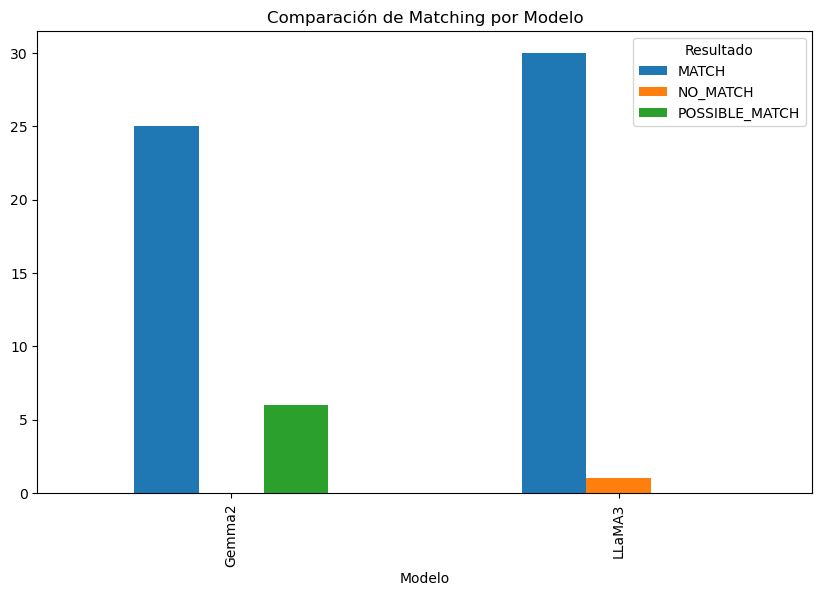

In [98]:
df_results = pd.DataFrame(results)

# Contar la cantidad de coincidencias por modelo
summary = df_results.groupby(["Modelo", "Resultado"]).size().unstack(fill_value=0)

# Mostrar la tabla de resultados detallados
print("\n=== Resultados Detallados ===\n")
print(df_results)

# Mostrar el resumen final por modelo
print("\n=== Resumen de Matches por Modelo ===\n")
print(summary)

# Visualización gráfica
summary.plot(kind='bar', figsize=(10, 6), title="Comparación de Matching por Modelo")


Como se puede ver, el modelo de Llama 3 tiene más seguridad a la hora de definir si hay un MATCH o no, xin embargo, cometió un error. Por otro lado, el módelo Gemma 2, no tuvo tanta seguridad con algunas predicciones, pero no cometió ningún error definitivo.

Ahora, se evaluan los modelos con datos que no deberían generar MATCH, al ser compañías que no son la misma.


Procesando con el modelo: Gemma2 (gemma2-9b-it)...


Procesando con el modelo: LLaMA3 (llama3-8b-8192)...


=== Resultados Detallados ===

    Modelo   Empresa 1 (Original)             Empresa 2 (Original)  \
0   Gemma2             Google LLC                Coca-Cola Company   
1   Gemma2                   IBM.  International Bussines Machines   
2   Gemma2        Amazon.com Inc.                      Pfizer Inc.   
3   Gemma2  Microsoft Corporation                        Nike Inc.   
4   Gemma2         Meta Platforms         Toyota Motor Corporation   
5   Gemma2        IBM Corporation         Starbucks Coffee Company   
6   Gemma2           Tesla Motors           McDonald's Corporation   
7   Gemma2              Twitterc.                          Twittch   
8   Gemma2    Samsung Electronics                    Goldman Sachs   
9   Gemma2          Cisco Systems                      Nestle S.A.   
10  Gemma2           Twitter Inc.                     PepsiCo Inc.   
11  Gemma2          

<Axes: title={'center': 'Comparación de Matching por Modelo'}, xlabel='Modelo'>

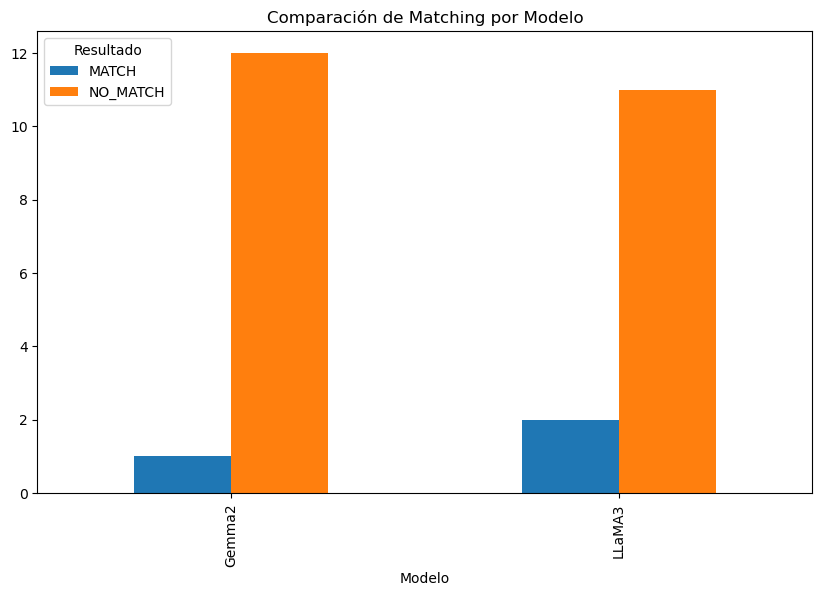

In [86]:
non_matching_company_pairs = [
    ("Google LLC", "Coca-Cola Company"),
    ("Amazon.com Inc.", "Pfizer Inc."),
    ("Microsoft Corporation", "Nike Inc."),
    ("Meta Platforms", "Toyota Motor Corporation"),
    ("IBM Corporation", "Starbucks Coffee Company"),
    ("Tesla Motors", "McDonald's Corporation"),
    ("Twitterc.", "Twittch"),
    ("Samsung Electronics", "Goldman Sachs"),
    ("Cisco Systems", "Nestle S.A."),
    ("Twitter Inc.", "PepsiCo Inc."),
    ("Snapchat Inc.", "Exxon Mobil Corporation"),
    ("Spotify Technology", "Bank of America"),]

resultsnm = []

# Recorrer la lista de pares de empresas
for model_name, model_id in models.items():
    print(f"\nProcesando con el modelo: {model_name} ({model_id})...\n")
    
    for name1, name2 in non_matching_company_pairs:
        normalized_name1 = normalize_entity(name1, model_id)
        normalized_name2 = normalize_entity(name2, model_id)

        match_result = match_entities(normalized_name1, normalized_name2, model_id)

        resultsnm.append({
            "Modelo": model_name,
            "Empresa 1 (Original)": name1,
            "Empresa 2 (Original)": name2,
            "Empresa 1 (Normalizada)": normalized_name1,
            "Empresa 2 (Normalizada)": normalized_name2,
            "Resultado": match_result
        })

df_resultsnm = pd.DataFrame(resultsnm)

# Contar la cantidad de coincidencias por modelo
summary = df_resultsnm.groupby(["Modelo", "Resultado"]).size().unstack(fill_value=0)

# Mostrar la tabla de resultados detallados
print("\n=== Resultados Detallados ===\n")
print(df_resultsnm)

# Mostrar el resumen final por modelo
print("\n=== Resumen de Matches por Modelo ===\n")
print(summary)

# Visualización gráfica
summary.plot(kind='bar', figsize=(10, 6), title="Comparación de Matching por Modelo")


Podemos evidenciar que el modelo Gemma 2 no cometió ningún error, catalogando todas las evaluaciones como NO MATCH, sin embargo, el modelo Llama 3 si cometió un error que también fue repetido por el algoritmo creado al comienzo del ejercicio.

### Presentación del enfoque hibrído que minimiza los llamados a la API
Se usará Llama 3 para el uso del enfoque hubrído, el cuál, primero usa elalgoritmo BERT creado ateriormente y si presenta dudas con respecto a algún par de compañías, utiliza a Llama 3, además se incorpra el uso del Caché para minimizar llamados a la API

Usando LLaMA3 para validar Google LLC vs Alphabet Inc.
Usando LLaMA3 para validar Meta Platforms vs Facebook Inc.
Usando LLaMA3 para validar Amazon.com Inc. vs Amazon Inc.
Usando LLaMA3 para validar Apple Inc. vs Apple Incorporated
Usando LLaMA3 para validar IBM Corporation vs International Business Machines
Usando LLaMA3 para validar Coca Cola Company vs Coca-Cola Co.

=== Resultados del Matching Híbrido (BERT + LLaMA3) ===

               Empresa 1                        Empresa 2      Resultado
0             Google LLC                    Alphabet Inc.  MATCH (LLaMA)
1         Meta Platforms                    Facebook Inc.  MATCH (LLaMA)
2        Amazon.com Inc.                      Amazon Inc.  MATCH (LLaMA)
3           Tesla Motors                       Tesla Inc.   MATCH (BERT)
4  Microsoft Corporation                  Microsoft Corp.   MATCH (BERT)
5             Apple Inc.               Apple Incorporated  MATCH (LLaMA)
6        IBM Corporation  International Business Machines  

<Axes: title={'center': 'Distribución de Matches (BERT vs LLaMA3)'}, xlabel='Resultado'>

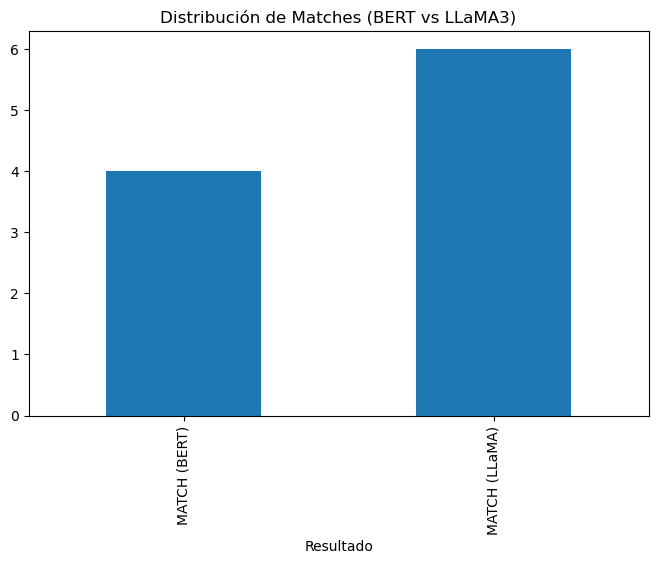

In [131]:
# Caché para reducir llamadas repetidas a la API
cache = {}
# Estrategia híbrida de matching (BERT + LLaMA3)
def hybrid_matching(entity1, entity2, bert_threshold=0.85):
    """
    Estrategia híbrida: primero usa BERT localmente, si no es claro, llama a Groq API.
    """
    cache_key = f"{entity1}_{entity2}"
    if cache_key in cache:
        print(f"Usando caché para: {entity1} vs {entity2}")
        return cache[cache_key]

    bert_match = match_companies_bert(entity1, entity2, threshold=bert_threshold)
    if bert_match:
        result = "MATCH (BERT)"
    else:
        print(f"Usando LLaMA3 para validar {entity1} vs {entity2}")
        result = f"{match_entities(entity1, entity2,"llama3-8b-8192")} (LLaMA)"
    
    cache[cache_key] = result
    return result

# Lista de empresas para prueba
company_pairs = [
    ("Google LLC", "Alphabet Inc."),
    ("Meta Platforms", "Facebook Inc."),
    ("Amazon.com Inc.", "Amazon Inc."),
    ("Tesla Motors", "Tesla Inc."),
    ("Microsoft Corporation", "Microsoft Corp."),
    ("Apple Inc.", "Apple Incorporated"),
    ("IBM Corporation", "International Business Machines"),
    ("Coca Cola Company", "Coca-Cola Co."),
    ("PepsiCo Inc.", "Pepsi Cola"),
    ("Oracle Corporation", "Oracle Corp.")
]

# Ejecutar el matching híbrido
results = []
for name1, name2 in company_pairs:
    result = hybrid_matching(name1, name2)
    results.append({
        "Empresa 1": name1,
        "Empresa 2": name2,
        "Resultado": result
    })

# Convertir a DataFrame para mejor visualización
df_results = pd.DataFrame(results)

# Contar la cantidad de resultados por categoría
summary = df_results.groupby("Resultado").size()

# Mostrar resultados
print("\n=== Resultados del Matching Híbrido (BERT + LLaMA3) ===\n")
print(df_results)
print("\n=== Resumen del Matching Híbrido ===\n")
print(summary)

# Visualización gráfica de los resultados
summary.plot(kind='bar', figsize=(8, 5), title="Distribución de Matches (BERT vs LLaMA3)")


### Casos de uso avanzado
1. Extracción de información adicional de las descripciones

In [137]:
def extract_information_with_llm(company_description):
    """
    Extrae información clave de la descripción de una empresa utilizando Groq API.
    """
    prompt = f"""
    Extrae la siguiente información de la descripción de la empresa:
    - Sector
    - País de origen
    - Tipo de negocio
    
    Descripción: {company_description}
    
    Formato esperado:
    {{ "sector": "Technology", "country": "USA", "business_type": "Corporation" }}
    """

    try:
        response = client.chat.completions.create(
            model="llama3-8b-8192",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error al extraer información: {e}")
        return None

# Prueba
description = "Google LLC is a multinational technology company based in the USA."
print(extract_information_with_llm(description))


La información extraída es:

{ "sector": "Technology", "country": "USA", "business_type": "Multinational Corporation" }

Nota: Como la empresa se describe como "multinational", no como "corporation", he utilizado ese término en lugar de "corporation".


2. Categorización automática de las compañías   

In [140]:
def categorize_company(company_name):
    """
    Clasifica la empresa en una categoría usando Groq API.
    """
    prompt = f"""
    Clasifica la empresa {company_name} en una de las siguientes categorías:
    - Tecnología
    - Finanzas
    - Retail
    - Transporte
    - Salud
    - Energía
    
    Solo devuelve la categoría correspondiente.
    """

    try:
        response = client.chat.completions.create(
            model="llama3-8b-8192",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error en la categorización: {e}")
        return None

# Prueba
print(categorize_company("Tesla Inc."))
print(categorize_company("Bank of America"))


Tecnología
Finanzas


3. Detección de anomalías en los datos

In [145]:
def detect_anomalies(entity_name):
    """
    Detecta si un nombre de empresa contiene anomalías o errores.
    """
    prompt = f"""
    Analiza el siguiente nombre de empresa: {entity_name}.
    Responde con:
    - OK si el nombre parece correcto.
    - ANOMALY si el nombre contiene errores o datos inconsistentes.
    """

    try:
        response = client.chat.completions.create(
            model="llama3-8b-8192",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error en la detección de anomalías: {e}")
        return None

# Prueba
print(detect_anomalies("Gooogle LLC"))
print(detect_anomalies("Microsoft Corporation")) 


ANOMALY

El nombre de empresa "Gooogle LLC" contiene un error. La empresa correcta se llama Google LLC, no Gooogle.
OK
